In [148]:
import pandas as pd

In [149]:
df = pd.read_csv("Nassau Candy Distributor.csv")

In [150]:
print(df.shape)

(10194, 18)


In [151]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [152]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [154]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Country/Region,0
City,0
State/Province,0
Postal Code,0


In [155]:
df.duplicated().sum()

np.int64(0)

In [156]:
df[["Sales", "Units", "Gross Profit", "Cost"]].describe()

,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,13.908537,3.791838,9.166451,4.742087
std,11.341020,2.228317,6.643740,5.061647
min,1.250000,1.000000,0.250000,0.600000
25%,7.200000,2.000000,4.900000,2.400000
50%,10.800000,3.000000,7.470000,3.600000
75%,18.000000,5.000000,12.250000,5.700000
max,260.000000,14.000000,130.000000,130.000000


In [157]:
calculated_profit = df["Sales"] - df["Cost"]

difference = df["Gross Profit"] - calculated_profit

difference.describe()

,0
count,1.019400e+04
mean,-3.609913e-16
std,8.618580e-16
min,-3.552714e-15
25%,-8.881784e-16
50%,0.000000e+00
75%,0.000000e+00
max,7.105427e-15


In [158]:
df[["Order Date", "Ship Date"]].head(10)

,Order Date,Ship Date
0,03-01-2024,30-06-2026
1,04-01-2024,01-07-2026
2,04-01-2024,01-07-2026
3,04-01-2024,01-07-2026
4,05-01-2024,05-07-2026
5,06-01-2024,03-07-2026
6,06-01-2024,03-07-2026
7,06-01-2024,30-06-2026
8,06-01-2024,03-07-2026
9,06-01-2024,03-07-2026


In [159]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d-%m-%Y"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d-%m-%Y"
)

In [160]:
df[["Order Date", "Ship Date"]].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [161]:
print("Missing Order Dates:", df["Order Date"].isna().sum())
print("Missing Ship Dates:", df["Ship Date"].isna().sum())

Missing Order Dates: 0
Missing Ship Dates: 0


In [162]:
print("Order Date:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

print("\nShip Date:")
print(df["Ship Date"].min(), "to", df["Ship Date"].max())

Order Date:
2024-01-02 00:00:00 to 2025-12-31 00:00:00

Ship Date:
2026-06-30 00:00:00 to 2030-06-28 00:00:00


In [163]:
df["Ship Date"] < df["Order Date"]

,0
0,False
1,False
2,False
3,False
4,False
...,...
10189,False
10190,False
10191,False
10192,False


In [164]:
(df["Ship Date"] < df["Order Date"]).sum()

np.int64(0)

In [165]:
df["Division"].value_counts()

,count
Division,
Chocolate,9844
Other,310
Sugar,40


In [166]:
df["Region"].value_counts()

,count
Region,
Pacific,3253
Atlantic,2986
Interior,2335
Gulf,1620


In [167]:
df["Country/Region"].value_counts()

,count
Country/Region,
United States,9994
Canada,200


In [168]:
df["Ship Mode"].value_counts()

,count
Ship Mode,
Standard Class,6120
Second Class,1979
First Class,1548
Same Day,547


In [169]:
df["Product ID"].nunique()

15

In [170]:
df["Product Name"].unique()

array(['Wonka Bar - Milk Chocolate', 'Wonka Bar - Triple Dazzle Caramel',
       'Wonka Bar - Nutty Crunch Surprise',
       'Wonka Bar -Scrumdiddlyumptious', 'Wonka Bar - Fudge Mallows',
       'Wonka Gum', 'Kazookles', 'Lickable Wallpaper',
       'Fizzy Lifting Drinks', 'Laffy Taffy', 'SweeTARTS', 'Nerds',
       'Hair Toffee', 'Everlasting Gobstopper', 'Fun Dip'], dtype=object)

In [171]:
df.groupby("Product ID")["Product Name"].nunique()

,Product Name
Product ID,
CHO-FUD-51000,1
CHO-MIL-31000,1
CHO-NUT-13000,1
CHO-SCR-58000,1
CHO-TRI-54000,1
OTH-FIZ-56000,1
OTH-GUM-21000,1
OTH-KAZ-38000,1
OTH-LIC-15000,1


In [172]:
df.groupby("Product ID")["Division"].nunique()

,Division
Product ID,
CHO-FUD-51000,1
CHO-MIL-31000,1
CHO-NUT-13000,1
CHO-SCR-58000,1
CHO-TRI-54000,1
OTH-FIZ-56000,1
OTH-GUM-21000,1
OTH-KAZ-38000,1
OTH-LIC-15000,1


In [173]:
print("Minimum Units:", df["Units"].min())
print("Zero Units:", (df["Units"] == 0).sum())
print("Negative Units:", (df["Units"] < 0).sum())

Minimum Units: 1
Zero Units: 0
Negative Units: 0


In [174]:
print("Minimum Sales:", df["Sales"].min())
print("Zero Sales:", (df["Sales"] == 0).sum())
print("Negative Sales:", (df["Sales"] < 0).sum())

Minimum Sales: 1.25
Zero Sales: 0
Negative Sales: 0


In [175]:
print("Minimum Gross Profit:", df["Gross Profit"].min())
print("Zero Gross Profit:", (df["Gross Profit"] == 0).sum())
print("Negative Gross Profit:", (df["Gross Profit"] < 0).sum())

Minimum Gross Profit: 0.25
Zero Gross Profit: 0
Negative Gross Profit: 0


In [176]:
print("Minimum Cost:", df["Cost"].min())
print("Zero Cost:", (df["Cost"] == 0).sum())
print("Negative Cost:", (df["Cost"] < 0).sum())


Minimum Cost: 0.6
Zero Cost: 0
Negative Cost: 0


In [177]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 7.2
Q3: 18.0
IQR: 10.8
Lower Bound: -9.000000000000004
Upper Bound: 34.2


In [178]:
sales_outliers = df[df["Sales"] > upper_bound]

print("Number of Sales outliers:", len(sales_outliers))

Number of Sales outliers: 245


In [179]:
sales_outliers.sort_values("Sales", ascending=False)[
    ["Order ID", "Order Date", "Division", "Product Name",
     "Sales", "Units", "Gross Profit", "Cost"]
].head(10)

,Order ID,Order Date,Division,Product Name,Sales,Units,Gross Profit,Cost
365,US-2021-122336-OTH-LIC-15000,2024-04-13,Other,Lickable Wallpaper,260.0,13,130.0,130.0
5827,US-2023-124163-OTH-LIC-15000,2025-09-25,Other,Lickable Wallpaper,220.0,11,110.0,110.0
4831,US-2023-107202-OTH-LIC-15000,2025-05-21,Other,Lickable Wallpaper,200.0,10,100.0,100.0
6472,US-2023-164770-OTH-LIC-15000,2025-12-02,Other,Lickable Wallpaper,200.0,10,100.0,100.0
1208,US-2021-147900-OTH-LIC-15000,2024-09-23,Other,Lickable Wallpaper,180.0,9,90.0,90.0
8534,US-2024-140326-OTH-LIC-15000,2025-09-04,Other,Lickable Wallpaper,180.0,9,90.0,90.0
6980,US-2024-164147-OTH-LIC-15000,2025-02-02,Other,Lickable Wallpaper,180.0,9,90.0,90.0
1789,US-2021-106376-OTH-LIC-15000,2024-12-05,Other,Lickable Wallpaper,160.0,8,80.0,80.0
5206,US-2023-136924-OTH-LIC-15000,2025-07-14,Other,Lickable Wallpaper,160.0,8,80.0,80.0
1961,US-2021-138247-OTH-LIC-15000,2024-12-24,Other,Lickable Wallpaper,140.0,7,70.0,70.0


In [180]:
Q1_profit = df["Gross Profit"].quantile(0.25)
Q3_profit = df["Gross Profit"].quantile(0.75)

IQR_profit = Q3_profit - Q1_profit

upper_profit = Q3_profit + 1.5 * IQR_profit

print("Q1:", Q1_profit)
print("Q3:", Q3_profit)
print("IQR:", IQR_profit)
print("Upper Bound:", upper_profit)

Q1: 4.9
Q3: 12.25
IQR: 7.35
Upper Bound: 23.275


In [181]:
profit_outliers = df[df["Gross Profit"] > upper_profit]

print("Number of Gross Profit outliers:", len(profit_outliers))

Number of Gross Profit outliers: 217


In [182]:
profit_outliers.sort_values("Gross Profit", ascending=False)[
    ["Order ID", "Order Date", "Division", "Product Name",
     "Sales", "Units", "Gross Profit", "Cost"]
].head(10)

,Order ID,Order Date,Division,Product Name,Sales,Units,Gross Profit,Cost
365,US-2021-122336-OTH-LIC-15000,2024-04-13,Other,Lickable Wallpaper,260.0,13,130.0,130.0
5827,US-2023-124163-OTH-LIC-15000,2025-09-25,Other,Lickable Wallpaper,220.0,11,110.0,110.0
4831,US-2023-107202-OTH-LIC-15000,2025-05-21,Other,Lickable Wallpaper,200.0,10,100.0,100.0
6472,US-2023-164770-OTH-LIC-15000,2025-12-02,Other,Lickable Wallpaper,200.0,10,100.0,100.0
1208,US-2021-147900-OTH-LIC-15000,2024-09-23,Other,Lickable Wallpaper,180.0,9,90.0,90.0
6980,US-2024-164147-OTH-LIC-15000,2025-02-02,Other,Lickable Wallpaper,180.0,9,90.0,90.0
8534,US-2024-140326-OTH-LIC-15000,2025-09-04,Other,Lickable Wallpaper,180.0,9,90.0,90.0
5206,US-2023-136924-OTH-LIC-15000,2025-07-14,Other,Lickable Wallpaper,160.0,8,80.0,80.0
1789,US-2021-106376-OTH-LIC-15000,2024-12-05,Other,Lickable Wallpaper,160.0,8,80.0,80.0
6124,US-2023-163328-OTH-LIC-15000,2025-11-04,Other,Lickable Wallpaper,140.0,7,70.0,70.0


In [183]:
Q1_cost = df["Cost"].quantile(0.25)
Q3_cost = df["Cost"].quantile(0.75)

IQR_cost = Q3_cost - Q1_cost

upper_cost = Q3_cost + 1.5 * IQR_cost

print("Q1:", Q1_cost)
print("Q3:", Q3_cost)
print("IQR:", IQR_cost)
print("Upper Bound:", upper_cost)

Q1: 2.4
Q3: 5.7
IQR: 3.3000000000000003
Upper Bound: 10.65


In [184]:
cost_outliers = df[df["Cost"] > upper_cost]

print("Number of Cost outliers:", len(cost_outliers))

Number of Cost outliers: 397


In [185]:
cost_outliers.sort_values("Cost", ascending=False)[
    ["Order ID", "Order Date", "Division", "Product Name",
     "Sales", "Units", "Gross Profit", "Cost"]
].head(10)

,Order ID,Order Date,Division,Product Name,Sales,Units,Gross Profit,Cost
365,US-2021-122336-OTH-LIC-15000,2024-04-13,Other,Lickable Wallpaper,260.0,13,130.0,130.0
5827,US-2023-124163-OTH-LIC-15000,2025-09-25,Other,Lickable Wallpaper,220.0,11,110.0,110.0
4831,US-2023-107202-OTH-LIC-15000,2025-05-21,Other,Lickable Wallpaper,200.0,10,100.0,100.0
6472,US-2023-164770-OTH-LIC-15000,2025-12-02,Other,Lickable Wallpaper,200.0,10,100.0,100.0
8534,US-2024-140326-OTH-LIC-15000,2025-09-04,Other,Lickable Wallpaper,180.0,9,90.0,90.0
6980,US-2024-164147-OTH-LIC-15000,2025-02-02,Other,Lickable Wallpaper,180.0,9,90.0,90.0
1208,US-2021-147900-OTH-LIC-15000,2024-09-23,Other,Lickable Wallpaper,180.0,9,90.0,90.0
1789,US-2021-106376-OTH-LIC-15000,2024-12-05,Other,Lickable Wallpaper,160.0,8,80.0,80.0
5206,US-2023-136924-OTH-LIC-15000,2025-07-14,Other,Lickable Wallpaper,160.0,8,80.0,80.0
1961,US-2021-138247-OTH-LIC-15000,2024-12-24,Other,Lickable Wallpaper,140.0,7,70.0,70.0


In [186]:
df["Gross Margin (%)"] = (
    df["Gross Profit"] / df["Sales"]
) * 100

In [187]:
df["Gross Margin (%)"].describe()

,Gross Margin (%)
count,10194.000000
mean,66.514045
std,6.721012
min,7.692308
25%,65.333333
50%,66.666667
75%,69.444444
max,80.000000


In [188]:
df["Profit per Unit"] = df["Gross Profit"] / df["Units"]

In [189]:
df["Profit per Unit"].describe()

,Profit per Unit
count,10194.000000
mean,2.412539
std,0.806007
min,0.250000
25%,2.400000
50%,2.450000
75%,2.490000
max,10.000000


In [190]:
total_sales = df["Sales"].sum()
total_profit = df["Gross Profit"].sum()

print("Total Sales:", total_sales)
print("Total Gross Profit:", total_profit)

Total Sales: 141783.63
Total Gross Profit: 93442.8


In [191]:
df["Profit Contribution (%)"] = (
    df["Gross Profit"] / total_profit
) * 100

In [192]:
df["Profit Contribution (%)"].describe()

,Profit Contribution (%)
count,10194.000000
mean,0.009810
std,0.007110
min,0.000268
25%,0.005244
50%,0.007994
75%,0.013110
max,0.139123


In [193]:
product_analysis = df.groupby("Product Name").agg(
    Total_Sales=("Sales", "sum"),
    Total_Units=("Units", "sum"),
    Total_Gross_Profit=("Gross Profit", "sum"),
    Total_Cost=("Cost", "sum")
).reset_index()

product_analysis

,Product Name,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost
0,Everlasting Gobstopper,130.00,13,104.00,26.00
1,Fizzy Lifting Drinks,78.75,21,47.25,31.50
2,Fun Dip,12.00,8,4.80,7.20
3,Hair Toffee,76.50,17,59.50,17.00
4,Kazookles,1205.75,371,92.75,1113.00
5,Laffy Taffy,53.73,27,33.48,20.25
6,Lickable Wallpaper,7860.00,393,3930.00,3930.00
7,Nerds,15.00,10,7.00,8.00
8,SweeTARTS,61.50,41,28.70,32.80
9,Wonka Bar - Fudge Mallows,24890.40,6914,16593.60,8296.80


In [194]:
product_analysis["Gross Margin (%)"] = (
    product_analysis["Total_Gross_Profit"]
    / product_analysis["Total_Sales"]
) * 100

In [195]:
product_analysis[
    ["Product Name", "Total_Sales", "Total_Gross_Profit", "Gross Margin (%)"]
]

,Product Name,Total_Sales,Total_Gross_Profit,Gross Margin (%)
0,Everlasting Gobstopper,130.00,104.00,80.000000
1,Fizzy Lifting Drinks,78.75,47.25,60.000000
2,Fun Dip,12.00,4.80,40.000000
3,Hair Toffee,76.50,59.50,77.777778
4,Kazookles,1205.75,92.75,7.692308
5,Laffy Taffy,53.73,33.48,62.311558
6,Lickable Wallpaper,7860.00,3930.00,50.000000
7,Nerds,15.00,7.00,46.666667
8,SweeTARTS,61.50,28.70,46.666667
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.666667


In [196]:
product_analysis.sort_values(
    "Total_Gross_Profit",
    ascending=False
)[
    ["Product Name", "Total_Sales", "Total_Gross_Profit", "Gross Margin (%)"]
]

,Product Name,Total_Sales,Total_Gross_Profit,Gross Margin (%)
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.444444
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.333333
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.923077
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.346705
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.666667
6,Lickable Wallpaper,7860.00,3930.00,50.000000
14,Wonka Gum,597.50,310.70,52.000000
0,Everlasting Gobstopper,130.00,104.00,80.000000
4,Kazookles,1205.75,92.75,7.692308
3,Hair Toffee,76.50,59.50,77.777778


In [197]:
product_analysis["Profit per Unit"] = (
    product_analysis["Total_Gross_Profit"]
    / product_analysis["Total_Units"]
)

In [198]:
product_analysis[
    ["Product Name", "Total_Units", "Total_Gross_Profit", "Profit per Unit"]
]

,Product Name,Total_Units,Total_Gross_Profit,Profit per Unit
0,Everlasting Gobstopper,13,104.00,8.00
1,Fizzy Lifting Drinks,21,47.25,2.25
2,Fun Dip,8,4.80,0.60
3,Hair Toffee,17,59.50,3.50
4,Kazookles,371,92.75,0.25
5,Laffy Taffy,27,33.48,1.24
6,Lickable Wallpaper,393,3930.00,10.00
7,Nerds,10,7.00,0.70
8,SweeTARTS,41,28.70,0.70
9,Wonka Bar - Fudge Mallows,6914,16593.60,2.40


In [199]:
product_analysis["Profit Contribution (%)"] = (
    product_analysis["Total_Gross_Profit"] / total_profit
) * 100

In [200]:
product_analysis[
    ["Product Name", "Total_Gross_Profit", "Profit Contribution (%)"]
].sort_values(
    "Profit Contribution (%)",
    ascending=False
)

,Product Name,Total_Gross_Profit,Profit Contribution (%)
13,Wonka Bar -Scrumdiddlyumptious,19357.50,20.715882
12,Wonka Bar - Triple Dazzle Caramel,18610.20,19.916141
10,Wonka Bar - Milk Chocolate,17443.37,18.667431
11,Wonka Bar - Nutty Crunch Surprise,16819.95,18.000263
9,Wonka Bar - Fudge Mallows,16593.60,17.758030
6,Lickable Wallpaper,3930.00,4.205782
14,Wonka Gum,310.70,0.332503
0,Everlasting Gobstopper,104.00,0.111298
4,Kazookles,92.75,0.099259
3,Hair Toffee,59.50,0.063675


In [201]:
pareto = product_analysis.sort_values(
    "Profit Contribution (%)",
    ascending=False
).copy()

pareto["Cumulative Profit Contribution (%)"] = (
    pareto["Profit Contribution (%)"].cumsum()
)

pareto[
    ["Product Name",
     "Profit Contribution (%)",
     "Cumulative Profit Contribution (%)"]
]

,Product Name,Profit Contribution (%),Cumulative Profit Contribution (%)
13,Wonka Bar -Scrumdiddlyumptious,20.715882,20.715882
12,Wonka Bar - Triple Dazzle Caramel,19.916141,40.632023
10,Wonka Bar - Milk Chocolate,18.667431,59.299454
11,Wonka Bar - Nutty Crunch Surprise,18.000263,77.299717
9,Wonka Bar - Fudge Mallows,17.758030,95.057747
6,Lickable Wallpaper,4.205782,99.263528
14,Wonka Gum,0.332503,99.596031
0,Everlasting Gobstopper,0.111298,99.707329
4,Kazookles,0.099259,99.806588
3,Hair Toffee,0.063675,99.870263


In [202]:
division_analysis = df.groupby("Division").agg(
    Total_Sales=("Sales", "sum"),
    Total_Units=("Units", "sum"),
    Total_Gross_Profit=("Gross Profit", "sum"),
    Total_Cost=("Cost", "sum")
).reset_index()

division_analysis

,Division,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost
0,Chocolate,131692.90,37275,88824.62,42868.28
1,Other,9663.25,1242,4333.45,5329.80
2,Sugar,427.48,137,284.73,142.75


In [203]:
division_analysis["Gross Margin (%)"] = (
    division_analysis["Total_Gross_Profit"]
    / division_analysis["Total_Sales"]
) * 100

division_analysis[
    ["Division", "Total_Sales", "Total_Gross_Profit", "Gross Margin (%)"]
]

,Division,Total_Sales,Total_Gross_Profit,Gross Margin (%)
0,Chocolate,131692.90,88824.62,67.448298
1,Other,9663.25,4333.45,44.844643
2,Sugar,427.48,284.73,66.606625


In [204]:
division_analysis["Profit Contribution (%)"] = (
    division_analysis["Total_Gross_Profit"]
    / division_analysis["Total_Gross_Profit"].sum()
) * 100

division_analysis[
    ["Division", "Total_Gross_Profit", "Profit Contribution (%)"]
].sort_values(
    "Profit Contribution (%)",
    ascending=False
)

,Division,Total_Gross_Profit,Profit Contribution (%)
0,Chocolate,88824.62,95.057747
1,Other,4333.45,4.637543
2,Sugar,284.73,0.304710


In [205]:
region_analysis = df.groupby("Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Units=("Units", "sum"),
    Total_Gross_Profit=("Gross Profit", "sum"),
    Total_Cost=("Cost", "sum")
).reset_index()

region_analysis

,Region,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost
0,Atlantic,41197.24,11159,26973.70,14223.54
1,Gulf,22247.26,6209,14700.67,7546.59
2,Interior,32037.60,8820,21282.49,10755.11
3,Pacific,46301.53,12466,30485.94,15815.59


In [206]:
region_analysis["Gross Margin (%)"] = (
    region_analysis["Total_Gross_Profit"]
    / region_analysis["Total_Sales"]
) * 100

region_analysis[
    ["Region", "Total_Sales", "Total_Gross_Profit", "Gross Margin (%)"]
].sort_values(
    "Gross Margin (%)",
    ascending=False
)

,Region,Total_Sales,Total_Gross_Profit,Gross Margin (%)
2,Interior,32037.60,21282.49,66.429726
1,Gulf,22247.26,14700.67,66.078564
3,Pacific,46301.53,30485.94,65.842187
0,Atlantic,41197.24,26973.70,65.474532


In [207]:
region_analysis["Profit Contribution (%)"] = (
    region_analysis["Total_Gross_Profit"]
    / region_analysis["Total_Gross_Profit"].sum()
) * 100

region_analysis[
    ["Region", "Total_Gross_Profit", "Profit Contribution (%)"]
].sort_values(
    "Profit Contribution (%)",
    ascending=False
)

,Region,Total_Gross_Profit,Profit Contribution (%)
3,Pacific,30485.94,32.625242
0,Atlantic,26973.70,28.866537
2,Interior,21282.49,22.775955
1,Gulf,14700.67,15.732266


In [208]:
ship_mode_analysis = df.groupby("Ship Mode").agg(
    Total_Sales=("Sales", "sum"),
    Total_Units=("Units", "sum"),
    Total_Gross_Profit=("Gross Profit", "sum"),
    Total_Cost=("Cost", "sum")
).reset_index()

ship_mode_analysis

,Ship Mode,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost
0,First Class,21319.39,5724,14011.09,7308.30
1,Same Day,7113.67,1975,4700.73,2412.94
2,Second Class,27860.22,7546,18306.52,9553.70
3,Standard Class,85490.35,23409,56424.46,29065.89


In [209]:
ship_mode_analysis["Gross Margin (%)"] = (
    ship_mode_analysis["Total_Gross_Profit"]
    / ship_mode_analysis["Total_Sales"]
) * 100

ship_mode_analysis[
    ["Ship Mode", "Total_Sales", "Total_Gross_Profit", "Gross Margin (%)"]
].sort_values(
    "Gross Margin (%)",
    ascending=False
)

,Ship Mode,Total_Sales,Total_Gross_Profit,Gross Margin (%)
1,Same Day,7113.67,4700.73,66.080237
3,Standard Class,85490.35,56424.46,66.000970
0,First Class,21319.39,14011.09,65.719939
2,Second Class,27860.22,18306.52,65.708455


In [210]:
customer_analysis = df.groupby("Customer ID").agg(
    Total_Sales=("Sales", "sum"),
    Total_Units=("Units", "sum"),
    Total_Gross_Profit=("Gross Profit", "sum"),
    Total_Cost=("Cost", "sum")
).reset_index()

customer_analysis.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

,Customer ID,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost
2326,131807,454.40,63,256.60,197.80
1124,115238,380.50,110,249.30,131.20
1637,122336,352.20,39,193.44,158.76
4690,164756,304.14,35,166.42,137.72
1770,124163,247.35,19,127.95,119.40
4692,164770,232.40,19,122.50,109.90
1859,125388,216.00,19,115.00,101.00
4615,163790,208.95,31,113.53,95.42
4644,164147,204.65,16,107.25,97.40
2939,140326,202.05,15,104.85,97.20


In [211]:
customer_analysis.sort_values(
    "Total_Gross_Profit",
    ascending=False
).head(10)

,Customer ID,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost
2326,131807,454.40,63,256.60,197.80
1124,115238,380.50,110,249.30,131.20
1637,122336,352.20,39,193.44,158.76
4690,164756,304.14,35,166.42,137.72
2887,139675,202.00,60,134.40,67.60
3748,151799,197.60,58,132.52,65.08
1770,124163,247.35,19,127.95,119.40
9,100111,182.41,52,125.93,56.48
4692,164770,232.40,19,122.50,109.90
1429,119508,177.14,50,122.34,54.80


In [212]:
customer_analysis["Gross Margin (%)"] = (
    customer_analysis["Total_Gross_Profit"]
    / customer_analysis["Total_Sales"]
) * 100

customer_analysis[
    ["Customer ID", "Total_Sales", "Total_Gross_Profit", "Gross Margin (%)"]
].sort_values(
    "Gross Margin (%)",
    ascending=False
).head(10)

,Customer ID,Total_Sales,Total_Gross_Profit,Gross Margin (%)
435,105662,50.47,39.47,78.204874
3573,149146,9.00,7.00,77.777778
4270,158834,29.70,22.50,75.757576
4165,157490,104.96,78.90,75.171494
4727,165323,33.30,25.00,75.075075
25,100314,50.50,37.34,73.940594
1982,127117,17.45,12.45,71.346705
3222,144302,6.98,4.98,71.346705
3227,144365,13.96,9.96,71.346705
3229,144393,13.96,9.96,71.346705


In [213]:
customer_analysis[
    ["Customer ID", "Total_Sales", "Total_Gross_Profit", "Gross Margin (%)"]
].sort_values(
    "Gross Margin (%)",
    ascending=True
).head(10)

,Customer ID,Total_Sales,Total_Gross_Profit,Gross Margin (%)
685,109211,3.25,0.25,7.692308
629,108350,13.00,1.00,7.692308
1828,124898,22.75,1.75,7.692308
1758,123981,3.25,0.25,7.692308
1377,118857,16.25,1.25,7.692308
551,107314,9.75,0.75,7.692308
1319,117926,3.25,0.25,7.692308
1312,117849,9.75,0.75,7.692308
4463,161767,6.50,0.50,7.692308
881,111864,6.50,0.50,7.692308


In [214]:
customer_analysis[
    customer_analysis["Total_Sales"] >= 100
].sort_values(
    "Gross Margin (%)",
    ascending=False
)[
    ["Customer ID", "Total_Sales", "Total_Gross_Profit", "Gross Margin (%)"]
].head(10)

,Customer ID,Total_Sales,Total_Gross_Profit,Gross Margin (%)
4165,157490,104.96,78.90,75.171494
4029,155586,106.68,74.88,70.191226
1415,119291,102.84,71.80,69.817192
793,110786,127.51,88.91,69.727864
3262,144806,111.07,77.07,69.388674
804,110905,104.36,72.22,69.202760
1429,119508,177.14,122.34,69.064017
9,100111,182.41,125.93,69.036785
246,103135,113.66,78.36,68.942460
2903,139892,129.06,88.90,68.882690


In [215]:
customer_analysis.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

,Customer ID,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin (%)
2326,131807,454.40,63,256.60,197.80,56.470070
1124,115238,380.50,110,249.30,131.20,65.519054
1637,122336,352.20,39,193.44,158.76,54.923339
4690,164756,304.14,35,166.42,137.72,54.718222
1770,124163,247.35,19,127.95,119.40,51.728320
4692,164770,232.40,19,122.50,109.90,52.710843
1859,125388,216.00,19,115.00,101.00,53.240741
4615,163790,208.95,31,113.53,95.42,54.333573
4644,164147,204.65,16,107.25,97.40,52.406548
2939,140326,202.05,15,104.85,97.20,51.893096


In [216]:
customer_analysis.sort_values(
    "Total_Units",
    ascending=False
).head(10)

,Customer ID,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin (%)
1124,115238,380.50,110,249.30,131.20,65.519054
2326,131807,454.40,63,256.60,197.80,56.470070
2887,139675,202.00,60,134.40,67.60,66.534653
3748,151799,197.60,58,132.52,65.08,67.064777
9,100111,182.41,52,125.93,56.48,69.036785
1429,119508,177.14,50,122.34,54.80,69.064017
2146,129322,180.75,49,120.05,60.70,66.417704
900,112109,164.50,48,107.06,57.44,65.082067
441,105732,167.75,46,112.33,55.42,66.962742
1280,117457,167.94,46,112.42,55.52,66.940574


In [217]:
customer_analysis["Profit Contribution (%)"] = (
    customer_analysis["Total_Gross_Profit"]
    / customer_analysis["Total_Gross_Profit"].sum()
) * 100

customer_analysis[
    ["Customer ID", "Total_Gross_Profit", "Profit Contribution (%)"]
].sort_values(
    "Profit Contribution (%)",
    ascending=False
).head(10)

,Customer ID,Total_Gross_Profit,Profit Contribution (%)
2326,131807,256.60,0.274606
1124,115238,249.30,0.266794
1637,122336,193.44,0.207014
4690,164756,166.42,0.178098
2887,139675,134.40,0.143831
3748,151799,132.52,0.141819
1770,124163,127.95,0.136929
9,100111,125.93,0.134767
4692,164770,122.50,0.131096
1429,119508,122.34,0.130925


In [218]:
customer_pareto = customer_analysis.sort_values(
    "Total_Gross_Profit",
    ascending=False
).copy()

customer_pareto["Cumulative Profit Contribution (%)"] = (
    customer_pareto["Profit Contribution (%)"].cumsum()
)

customer_pareto[
    [
        "Customer ID",
        "Total_Gross_Profit",
        "Profit Contribution (%)",
        "Cumulative Profit Contribution (%)"
    ]
].head(20)

,Customer ID,Total_Gross_Profit,Profit Contribution (%),Cumulative Profit Contribution (%)
2326,131807,256.60,0.274606,0.274606
1124,115238,249.30,0.266794,0.541401
1637,122336,193.44,0.207014,0.748415
4690,164756,166.42,0.178098,0.926513
2887,139675,134.40,0.143831,1.070345
3748,151799,132.52,0.141819,1.212164
1770,124163,127.95,0.136929,1.349093
9,100111,125.93,0.134767,1.483860
4692,164770,122.50,0.131096,1.614956
1429,119508,122.34,0.130925,1.745881


In [219]:
print("Total Customers:", customer_analysis["Customer ID"].nunique())

Total Customers: 5044


In [220]:
customer_orders = df.groupby("Customer ID")["Order ID"].nunique()

customer_orders.describe()

,Order ID
count,5044.000000
mean,1.694885
std,0.999844
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,15.000000


In [221]:
customer_type = customer_orders.value_counts().sort_index()

customer_type

,count
Order ID,
1,2811
2,1351
3,602
4,223
5,42
6,9
9,1
10,2
15,3


In [222]:
one_time_customers = customer_type.loc[1]
repeat_customers = customer_type.loc[customer_type.index > 1].sum()

total_customers = customer_type.sum()

one_time_percentage = (one_time_customers / total_customers) * 100
repeat_percentage = (repeat_customers / total_customers) * 100

print("One-time customers:", one_time_customers)
print("Repeat customers:", repeat_customers)
print("One-time customer %:", one_time_percentage)
print("Repeat customer %:", repeat_percentage)

One-time customers: 2811
Repeat customers: 2233
One-time customer %: 55.72957969865187
Repeat customer %: 44.27042030134813


In [223]:
average_sales_per_customer = (
    customer_analysis["Total_Sales"].sum()
    / customer_analysis["Customer ID"].nunique()
)

print("Average Sales per Customer:", average_sales_per_customer)

Average Sales per Customer: 28.10936360031721


In [224]:
average_orders_per_customer = customer_orders.mean()

print("Average Orders per Customer:", average_orders_per_customer)

Average Orders per Customer: 1.6948850118953211


In [225]:
customer_segment = pd.cut(
    customer_orders,
    bins=[0, 1, 4, float("inf")],
    labels=["One-time", "Repeat", "Loyal"]
)

customer_segment_counts = customer_segment.value_counts()

customer_segment_counts

,count
Order ID,
One-time,2811
Repeat,2176
Loyal,57


In [226]:
customer_segment_percentage = (
    customer_segment_counts / customer_segment_counts.sum()
) * 100

customer_segment_percentage

,count
Order ID,
One-time,55.729580
Repeat,43.140365
Loyal,1.130056


In [227]:
customer_analysis["Customer Segment"] = customer_segment.values

segment_sales = customer_analysis.groupby("Customer Segment").agg(
    Total_Sales=("Total_Sales", "sum"),
    Customers=("Customer ID", "count")
)

segment_sales["Average_Sales_per_Customer"] = (
    segment_sales["Total_Sales"] / segment_sales["Customers"]
)

segment_sales

/tmp/ipykernel_850/2979509970.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_sales = customer_analysis.groupby("Customer Segment").agg(


,Total_Sales,Customers,Average_Sales_per_Customer
Customer Segment,,,
One-time,42634.21,2811,15.166919
Repeat,91656.64,2176,42.121618
Loyal,7492.78,57,131.452281


In [228]:
customer_analysis[
    ["Customer ID", "Total_Sales", "Total_Gross_Profit", "Gross Margin (%)"]
].sort_values(
    "Total_Gross_Profit",
    ascending=False
).head(10)

,Customer ID,Total_Sales,Total_Gross_Profit,Gross Margin (%)
2326,131807,454.40,256.60,56.470070
1124,115238,380.50,249.30,65.519054
1637,122336,352.20,193.44,54.923339
4690,164756,304.14,166.42,54.718222
2887,139675,202.00,134.40,66.534653
3748,151799,197.60,132.52,67.064777
1770,124163,247.35,127.95,51.728320
9,100111,182.41,125.93,69.036785
4692,164770,232.40,122.50,52.710843
1429,119508,177.14,122.34,69.064017


In [229]:
customer_analysis[
    (customer_analysis["Total_Sales"] >= 100) &
    (customer_analysis["Gross Margin (%)"] >= 65)
].sort_values(
    "Total_Gross_Profit",
    ascending=False
).head(10)

,Customer ID,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross Margin (%),Profit Contribution (%),Customer Segment
1124,115238,380.50,110,249.30,131.20,65.519054,0.266794,Loyal
2887,139675,202.00,60,134.40,67.60,66.534653,0.143831,Loyal
3748,151799,197.60,58,132.52,65.08,67.064777,0.141819,Loyal
9,100111,182.41,52,125.93,56.48,69.036785,0.134767,Loyal
1429,119508,177.14,50,122.34,54.80,69.064017,0.130925,Loyal
2146,129322,180.75,49,120.05,60.70,66.417704,0.128474,Loyal
1280,117457,167.94,46,112.42,55.52,66.940574,0.120309,Repeat
441,105732,167.75,46,112.33,55.42,66.962742,0.120213,Loyal
494,106439,162.14,45,109.86,52.28,67.756260,0.117569,Loyal
900,112109,164.50,48,107.06,57.44,65.082067,0.114573,Loyal


In [230]:
potential_loyal_customers = customer_analysis[
    (customer_analysis["Customer Segment"] == "Repeat") &
    (customer_analysis["Total_Sales"] >= 100) &
    (customer_analysis["Gross Margin (%)"] >= 65)
].sort_values(
    "Total_Gross_Profit",
    ascending=False
)

potential_loyal_customers[
    ["Customer ID", "Total_Sales", "Total_Gross_Profit",
     "Gross Margin (%)", "Customer Segment"]
].head(10)

,Customer ID,Total_Sales,Total_Gross_Profit,Gross Margin (%),Customer Segment
1280,117457,167.94,112.42,66.940574,Repeat
2988,140949,147.97,100.79,68.115158,Repeat
3284,145177,146.01,100.23,68.645983,Repeat
2394,132626,149.18,99.12,66.443223,Repeat
1975,126977,142.50,97.06,68.112281,Repeat
4201,157987,138.98,95.62,68.801266,Repeat
1162,115812,136.75,92.59,67.707495,Repeat
3745,151750,133.50,89.94,67.370787,Repeat
750,110156,131.96,89.64,67.929676,Repeat
793,110786,127.51,88.91,69.727864,Repeat


In [231]:
print("Potential Loyal Customers:", len(potential_loyal_customers))

Potential Loyal Customers: 50


In [232]:
potential_loyal_percentage = (
    len(potential_loyal_customers) / total_customers
) * 100

print("Potential Loyal Customer %:", potential_loyal_percentage)

Potential Loyal Customer %: 0.9912767644726407


In [233]:
potential_loyal_summary = potential_loyal_customers[
    ["Total_Sales", "Total_Gross_Profit", "Gross Margin (%)"]
].mean()

potential_loyal_summary

,0
Total_Sales,116.679800
Total_Gross_Profit,78.875400
Gross Margin (%),67.594165


In [234]:
potential_loyal_summary = potential_loyal_customers[
    ["Total_Sales", "Total_Gross_Profit", "Gross Margin (%)"]
].mean()

potential_loyal_summary

,0
Total_Sales,116.679800
Total_Gross_Profit,78.875400
Gross Margin (%),67.594165


In [235]:
potential_loyal_customers[
    ["Customer ID", "Total_Sales", "Total_Gross_Profit", "Gross Margin (%)"]
].head(10)

,Customer ID,Total_Sales,Total_Gross_Profit,Gross Margin (%)
1280,117457,167.94,112.42,66.940574
2988,140949,147.97,100.79,68.115158
3284,145177,146.01,100.23,68.645983
2394,132626,149.18,99.12,66.443223
1975,126977,142.50,97.06,68.112281
4201,157987,138.98,95.62,68.801266
1162,115812,136.75,92.59,67.707495
3745,151750,133.50,89.94,67.370787
750,110156,131.96,89.64,67.929676
793,110786,127.51,88.91,69.727864


In [236]:
potential_loyal_total_sales = potential_loyal_customers["Total_Sales"].sum()
potential_loyal_total_profit = potential_loyal_customers["Total_Gross_Profit"].sum()

print("Total Sales from Potential Loyal Customers:", potential_loyal_total_sales)
print("Total Profit from Potential Loyal Customers:", potential_loyal_total_profit)

Total Sales from Potential Loyal Customers: 5833.99
Total Profit from Potential Loyal Customers: 3943.77


In [237]:
potential_loyal_ids = potential_loyal_customers["Customer ID"]

potential_loyal_orders = df[
    df["Customer ID"].isin(potential_loyal_ids)
]

potential_loyal_products = (
    potential_loyal_orders
    .groupby("Product Name")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Units=("Units", "sum"),
        Total_Gross_Profit=("Gross Profit", "sum")
    )
    .sort_values("Total_Gross_Profit", ascending=False)
)

potential_loyal_products.head(10)

,Total_Sales,Total_Units,Total_Gross_Profit
Product Name,,,
Wonka Bar - Fudge Mallows,1321.20,367,880.80
Wonka Bar -Scrumdiddlyumptious,1263.60,351,877.50
Wonka Bar - Milk Chocolate,1244.75,383,808.13
Wonka Bar - Nutty Crunch Surprise,980.69,281,699.69
Wonka Bar - Triple Dazzle Caramel,963.75,257,629.65
Everlasting Gobstopper,60.00,6,48.00


In [238]:
potential_loyal_customers[
    ["Customer ID", "Total_Sales", "Total_Gross_Profit", "Gross Margin (%)"]
].sort_values(
    "Total_Gross_Profit",
    ascending=False
).head(10)

,Customer ID,Total_Sales,Total_Gross_Profit,Gross Margin (%)
1280,117457,167.94,112.42,66.940574
2988,140949,147.97,100.79,68.115158
3284,145177,146.01,100.23,68.645983
2394,132626,149.18,99.12,66.443223
1975,126977,142.50,97.06,68.112281
4201,157987,138.98,95.62,68.801266
1162,115812,136.75,92.59,67.707495
3745,151750,133.50,89.94,67.370787
750,110156,131.96,89.64,67.929676
793,110786,127.51,88.91,69.727864


In [239]:
loyal_avg = segment_sales.loc["Loyal"]

repeat_potential_avg = segment_sales.loc["Repeat"]

print("Loyal average sales:", loyal_avg["Average_Sales_per_Customer"])
print("Repeat average sales:", repeat_potential_avg["Average_Sales_per_Customer"])

Loyal average sales: 131.45228070175438
Repeat average sales: 42.12161764705883


In [240]:
additional_sales_opportunity = (
    50 * (131.45228070175438 - 42.12161764705883)
)

potential_additional_profit = (
    additional_sales_opportunity * 67.594165 / 100
)

print("Additional Sales Opportunity:", additional_sales_opportunity)
print("Potential Additional Gross Profit:", potential_additional_profit)

Additional Sales Opportunity: 4466.533152734777
Potential Additional Gross Profit: 3019.1157890392474


In [241]:
customer_analysis_sorted = customer_analysis.sort_values(
    "Total_Gross_Profit",
    ascending=False
).copy()

customer_analysis_sorted["Profit Contribution (%)"] = (
    customer_analysis_sorted["Total_Gross_Profit"]
    / customer_analysis_sorted["Total_Gross_Profit"].sum()
) * 100

customer_analysis_sorted["Cumulative Profit Contribution (%)"] = (
    customer_analysis_sorted["Profit Contribution (%)"].cumsum()
)

customers_for_80_percent = (
    customer_analysis_sorted[
        customer_analysis_sorted["Cumulative Profit Contribution (%)"] >= 80
    ]
    .index[0] + 1
)

customer_percentage_for_80 = (
    customers_for_80_percent / len(customer_analysis_sorted)
) * 100

print("Customers needed for 80% of profit:", customers_for_80_percent)
print("Percentage of customers:", customer_percentage_for_80)

Customers needed for 80% of profit: 1875
Percentage of customers: 37.17287866772403


In [242]:
customer_segment_profit = customer_analysis.groupby(
    "Customer Segment"
).agg(
    Total_Sales=("Total_Sales", "sum"),
    Total_Gross_Profit=("Total_Gross_Profit", "sum"),
    Customers=("Customer ID", "count")
)

customer_segment_profit["Profit_per_Customer"] = (
    customer_segment_profit["Total_Gross_Profit"]
    / customer_segment_profit["Customers"]
)

customer_segment_profit

/tmp/ipykernel_850/2560409372.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_segment_profit = customer_analysis.groupby(


,Total_Sales,Total_Gross_Profit,Customers,Profit_per_Customer
Customer Segment,,,,
One-time,42634.21,28196.81,2811,10.030882
Repeat,91656.64,60453.87,2176,27.782109
Loyal,7492.78,4792.12,57,84.072281


In [243]:
customer_segment_profit["Profit_Contribution (%)"] = (
    customer_segment_profit["Total_Gross_Profit"]
    / customer_segment_profit["Total_Gross_Profit"].sum()
) * 100

customer_segment_profit[
    ["Total_Gross_Profit", "Customers", "Profit_per_Customer",
     "Profit_Contribution (%)"]
]

,Total_Gross_Profit,Customers,Profit_per_Customer,Profit_Contribution (%)
Customer Segment,,,,
One-time,28196.81,2811,10.030882,30.175476
Repeat,60453.87,2176,27.782109,64.696124
Loyal,4792.12,57,84.072281,5.128399


In [244]:
high_value_repeat = customer_analysis[
    (customer_analysis["Customer Segment"] == "Repeat") &
    (customer_analysis["Total_Sales"] >= 100) &
    (customer_analysis["Gross Margin (%)"] >= 65)
].sort_values(
    "Total_Gross_Profit",
    ascending=False
)

print("High-value Repeat Customers:", len(high_value_repeat))

high_value_repeat[
    ["Customer ID", "Total_Sales", "Total_Gross_Profit",
     "Gross Margin (%)"]
].head(10)

High-value Repeat Customers: 50


,Customer ID,Total_Sales,Total_Gross_Profit,Gross Margin (%)
1280,117457,167.94,112.42,66.940574
2988,140949,147.97,100.79,68.115158
3284,145177,146.01,100.23,68.645983
2394,132626,149.18,99.12,66.443223
1975,126977,142.50,97.06,68.112281
4201,157987,138.98,95.62,68.801266
1162,115812,136.75,92.59,67.707495
3745,151750,133.50,89.94,67.370787
750,110156,131.96,89.64,67.929676
793,110786,127.51,88.91,69.727864


In [245]:
high_value_repeat_sales = high_value_repeat["Total_Sales"].sum()
high_value_repeat_profit = high_value_repeat["Total_Gross_Profit"].sum()

print("Sales from High-Value Repeat Customers:", high_value_repeat_sales)
print("Profit from High-Value Repeat Customers:", high_value_repeat_profit)

Sales from High-Value Repeat Customers: 5833.99
Profit from High-Value Repeat Customers: 3943.77


In [246]:
high_value_repeat_sales_percentage = (
    high_value_repeat_sales / customer_analysis["Total_Sales"].sum()
) * 100

high_value_repeat_profit_percentage = (
    high_value_repeat_profit / customer_analysis["Total_Gross_Profit"].sum()
) * 100

print("Sales Contribution:", high_value_repeat_sales_percentage)
print("Profit Contribution:", high_value_repeat_profit_percentage)

Sales Contribution: 4.114713384048637
Profit Contribution: 4.22051779270313


**🎯 Business recommendation**
"The company should prioritize the 50 high-value repeat customers through loyalty programs, personalized offers, cross-selling, and targeted promotions to encourage them to become Loyal customers and increase their future purchase value."

And because we already calculated that Loyal customers average ₹131.45 in sales compared with ₹42.12 for Repeat customers, there is a strong opportunity to increase spending from this group.


In [247]:
high_value_repeat_avg_sales = (
    high_value_repeat["Total_Sales"].mean()
)

high_value_repeat_avg_profit = (
    high_value_repeat["Total_Gross_Profit"].mean()
)

high_value_repeat_avg_margin = (
    high_value_repeat["Gross Margin (%)"].mean()
)

print("Average Sales per High-Value Repeat Customer:",
      high_value_repeat_avg_sales)

print("Average Profit per High-Value Repeat Customer:",
      high_value_repeat_avg_profit)

print("Average Gross Margin:",
      high_value_repeat_avg_margin)

Average Sales per High-Value Repeat Customer: 116.6798
Average Profit per High-Value Repeat Customer: 78.8754
Average Gross Margin: 67.59416454311308


In [248]:
sales_uplift_per_customer = (
    segment_sales.loc["Loyal", "Average_Sales_per_Customer"]
    - high_value_repeat_avg_sales
)

profit_uplift_per_customer = (
    customer_segment_profit.loc["Loyal", "Profit_per_Customer"]
    - high_value_repeat_avg_profit
)

print("Potential Sales Uplift per Customer:", sales_uplift_per_customer)
print("Potential Profit Uplift per Customer:", profit_uplift_per_customer)

Potential Sales Uplift per Customer: 14.772480701754375
Potential Profit Uplift per Customer: 5.196880701754381


In [249]:
total_sales_uplift = (
    sales_uplift_per_customer * len(high_value_repeat)
)

total_profit_uplift = (
    profit_uplift_per_customer * len(high_value_repeat)
)

print("Total Potential Sales Uplift:", total_sales_uplift)
print("Total Potential Profit Uplift:", total_profit_uplift)

Total Potential Sales Uplift: 738.6240350877188
Total Potential Profit Uplift: 259.844035087719


In [250]:
high_value_repeat_ids = high_value_repeat["Customer ID"]

high_value_repeat_orders = df[
    df["Customer ID"].isin(high_value_repeat_ids)
]

high_value_repeat_products = (
    high_value_repeat_orders
    .groupby("Product Name")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Units=("Units", "sum"),
        Total_Gross_Profit=("Gross Profit", "sum")
    )
    .sort_values("Total_Gross_Profit", ascending=False)
)

high_value_repeat_products.head(10)

,Total_Sales,Total_Units,Total_Gross_Profit
Product Name,,,
Wonka Bar - Fudge Mallows,1321.20,367,880.80
Wonka Bar -Scrumdiddlyumptious,1263.60,351,877.50
Wonka Bar - Milk Chocolate,1244.75,383,808.13
Wonka Bar - Nutty Crunch Surprise,980.69,281,699.69
Wonka Bar - Triple Dazzle Caramel,963.75,257,629.65
Everlasting Gobstopper,60.00,6,48.00


In [251]:
high_value_repeat_products["Gross_Margin (%)"] = (
    high_value_repeat_products["Total_Gross_Profit"]
    / high_value_repeat_products["Total_Sales"]
) * 100

high_value_repeat_products[
    ["Total_Sales", "Total_Units", "Total_Gross_Profit", "Gross_Margin (%)"]
].sort_values(
    "Gross_Margin (%)",
    ascending=False
).head(10)

,Total_Sales,Total_Units,Total_Gross_Profit,Gross_Margin (%)
Product Name,,,,
Everlasting Gobstopper,60.00,6,48.00,80.000000
Wonka Bar - Nutty Crunch Surprise,980.69,281,699.69,71.346705
Wonka Bar -Scrumdiddlyumptious,1263.60,351,877.50,69.444444
Wonka Bar - Fudge Mallows,1321.20,367,880.80,66.666667
Wonka Bar - Triple Dazzle Caramel,963.75,257,629.65,65.333333
Wonka Bar - Milk Chocolate,1244.75,383,808.13,64.923077


In [252]:
high_value_repeat["Loyalty_Priority_Score"] = (
    high_value_repeat["Total_Gross_Profit"] *
    high_value_repeat["Gross Margin (%)"] / 100
)

high_value_repeat[
    ["Customer ID", "Total_Sales", "Total_Gross_Profit", "Gross Margin (%)",
     "Loyalty_Priority_Score"]
].sort_values(
    "Loyalty_Priority_Score",
    ascending=False
).head(10)

,Customer ID,Total_Sales,Total_Gross_Profit,Gross Margin (%),Loyalty_Priority_Score
1280,117457,167.94,112.42,66.940574,75.254593
3284,145177,146.01,100.23,68.645983,68.803869
2988,140949,147.97,100.79,68.115158,68.653268
1975,126977,142.50,97.06,68.112281,66.109780
2394,132626,149.18,99.12,66.443223,65.858523
4201,157987,138.98,95.62,68.801266,65.787771
1162,115812,136.75,92.59,67.707495,62.690370
793,110786,127.51,88.91,69.727864,61.995044
2903,139892,129.06,88.90,68.882690,61.236712
750,110156,131.96,89.64,67.929676,60.892161


In [253]:
top_10_priority = high_value_repeat.sort_values(
    "Loyalty_Priority_Score",
    ascending=False
).head(10)

top_10_profit = top_10_priority["Total_Gross_Profit"].sum()

top_10_profit_contribution = (
    top_10_profit / high_value_repeat["Total_Gross_Profit"].sum()
) * 100

print("Top 10 Priority Customer Profit:", top_10_profit)
print("Top 10 Profit Contribution among High-Value Repeat Customers:",
      top_10_profit_contribution)

Top 10 Priority Customer Profit: 965.28
Top 10 Profit Contribution among High-Value Repeat Customers: 24.476072387588523


In [254]:
high_value_repeat_order_counts = (
    high_value_repeat_orders
    .groupby("Customer ID")["Order ID"]
    .nunique()
)

print(
    "Average Orders per High-Value Repeat Customer:",
    high_value_repeat_order_counts.mean()
)

print(
    "Maximum Orders by a High-Value Repeat Customer:",
    high_value_repeat_order_counts.max()
)

Average Orders per High-Value Repeat Customer: 3.52
Maximum Orders by a High-Value Repeat Customer: 4


In [255]:
high_value_repeat_aov = (
    high_value_repeat_orders["Sales"].sum()
    / high_value_repeat_orders["Order ID"].nunique()
)

print("Average Order Value of High-Value Repeat Customers:",
      high_value_repeat_aov)

Average Order Value of High-Value Repeat Customers: 33.147670454545455


High-Value Repeat customers place approximately 2.08 times as many orders as the average customer, while maintaining a 67.59% average gross margin. This makes them a strong target for loyalty and upselling strategies.

In [256]:
aov_uplift = high_value_repeat_aov * 0.10

potential_aov = high_value_repeat_aov + aov_uplift

print("Current AOV:", high_value_repeat_aov)
print("Potential AOV:", potential_aov)
print("AOV Increase:", aov_uplift)

Current AOV: 33.147670454545455
Potential AOV: 36.4624375
AOV Increase: 3.3147670454545457


In [257]:
additional_sales_from_aov = (
    aov_uplift * high_value_repeat_order_counts.sum()
)

print("Additional Sales from AOV Increase:", additional_sales_from_aov)

Additional Sales from AOV Increase: 583.399


In [258]:
additional_profit_from_aov = (
    additional_sales_from_aov * high_value_repeat_avg_margin / 100
)

print(
    "Additional Profit from AOV Increase:",
    additional_profit_from_aov
)

Additional Profit from AOV Increase: 394.3436800028763


In [259]:
total_sales_opportunity = (
    additional_sales_opportunity +
    additional_sales_from_aov
)

total_profit_opportunity = (
    potential_additional_profit +
    additional_profit_from_aov
)

print("Total Potential Sales Opportunity:", total_sales_opportunity)
print("Total Potential Profit Opportunity:", total_profit_opportunity)

Total Potential Sales Opportunity: 5049.932152734777
Total Potential Profit Opportunity: 3413.4594690421236


In [260]:
top_20_percent_count = int(len(customer_analysis) * 0.20)

top_20_customers = (
    customer_analysis
    .sort_values("Total_Gross_Profit", ascending=False)
    .head(top_20_percent_count)
)

top_20_profit = top_20_customers["Total_Gross_Profit"].sum()

top_20_profit_percentage = (
    top_20_profit /
    customer_analysis["Total_Gross_Profit"].sum()
) * 100

print("Top 20% Customer Count:", top_20_percent_count)
print("Profit from Top 20% Customers:", top_20_profit)
print("Profit Contribution of Top 20%:", top_20_profit_percentage)

Top 20% Customer Count: 1008
Profit from Top 20% Customers: 45164.22
Profit Contribution of Top 20%: 48.33354736801552


In [261]:
customer_profit_sorted = customer_analysis.sort_values(
    "Total_Gross_Profit",
    ascending=False
)

total_profit = customer_analysis["Total_Gross_Profit"].sum()

for percentage in [10, 20, 30, 40, 50]:

    customer_count = int(len(customer_analysis) * percentage / 100)

    profit = customer_profit_sorted.head(customer_count)[
        "Total_Gross_Profit"
    ].sum()

    profit_percentage = (profit / total_profit) * 100

    print(
        f"Top {percentage}% customers: "
        f"{customer_count} customers → "
        f"{profit_percentage:.2f}% of profit"
    )

Top 10% customers: 504 customers → 31.07% of profit
Top 20% customers: 1008 customers → 48.33% of profit
Top 30% customers: 1513 customers → 61.30% of profit
Top 40% customers: 2017 customers → 71.49% of profit
Top 50% customers: 2522 customers → 79.79% of profit


In [262]:
segment_product_analysis = (
    df.merge(
        customer_analysis[["Customer ID", "Customer Segment"]],
        on="Customer ID",
        how="left"
    )
    .groupby(["Customer Segment", "Product Name"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Units=("Units", "sum"),
        Total_Gross_Profit=("Gross Profit", "sum")
    )
    .reset_index()
)

segment_product_analysis

/tmp/ipykernel_850/4265429947.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Customer Segment", "Product Name"])


,Customer Segment,Product Name,Total_Sales,Total_Units,Total_Gross_Profit
0,One-time,Everlasting Gobstopper,0.00,0,0.00
1,One-time,Fizzy Lifting Drinks,0.00,0,0.00
2,One-time,Fun Dip,1.50,1,0.60
3,One-time,Hair Toffee,9.00,2,7.00
4,One-time,Kazookles,338.00,104,26.00
5,One-time,Laffy Taffy,23.88,12,14.88
6,One-time,Lickable Wallpaper,1800.00,90,900.00
7,One-time,Nerds,6.00,4,2.80
8,One-time,SweeTARTS,28.50,19,13.30
9,One-time,Wonka Bar - Fudge Mallows,7491.60,2081,4994.40


In [263]:
segment_product_analysis = (
    df.merge(
        customer_analysis[["Customer ID", "Customer Segment"]],
        on="Customer ID",
        how="left"
    )
    .groupby(
        ["Customer Segment", "Product Name"],
        observed=True
    )
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Units=("Units", "sum"),
        Total_Gross_Profit=("Gross Profit", "sum")
    )
    .reset_index()
)

segment_product_analysis = segment_product_analysis[
    segment_product_analysis["Total_Gross_Profit"] > 0
]

segment_product_analysis

,Customer Segment,Product Name,Total_Sales,Total_Units,Total_Gross_Profit
0,One-time,Fun Dip,1.50,1,0.60
1,One-time,Hair Toffee,9.00,2,7.00
2,One-time,Kazookles,338.00,104,26.00
3,One-time,Laffy Taffy,23.88,12,14.88
4,One-time,Lickable Wallpaper,1800.00,90,900.00
5,One-time,Nerds,6.00,4,2.80
6,One-time,SweeTARTS,28.50,19,13.30
7,One-time,Wonka Bar - Fudge Mallows,7491.60,2081,4994.40
8,One-time,Wonka Bar - Milk Chocolate,8401.25,2585,5454.35
9,One-time,Wonka Bar - Nutty Crunch Surprise,7144.03,2047,5097.03


In [264]:
top_products_by_segment = (
    segment_product_analysis
    .sort_values(
        ["Customer Segment", "Total_Gross_Profit"],
        ascending=[True, False]
    )
    .groupby("Customer Segment", observed=True)
    .head(5)
)

top_products_by_segment

,Customer Segment,Product Name,Total_Sales,Total_Units,Total_Gross_Profit
11,One-time,Wonka Bar -Scrumdiddlyumptious,8449.20,2347,5867.50
10,One-time,Wonka Bar - Triple Dazzle Caramel,8771.25,2339,5730.55
8,One-time,Wonka Bar - Milk Chocolate,8401.25,2585,5454.35
9,One-time,Wonka Bar - Nutty Crunch Surprise,7144.03,2047,5097.03
7,One-time,Wonka Bar - Fudge Mallows,7491.60,2081,4994.40
26,Repeat,Wonka Bar -Scrumdiddlyumptious,17989.20,4997,12492.50
25,Repeat,Wonka Bar - Triple Dazzle Caramel,18408.75,4909,12027.05
23,Repeat,Wonka Bar - Milk Chocolate,17202.25,5293,11168.23
24,Repeat,Wonka Bar - Nutty Crunch Surprise,15450.23,4427,11023.23
22,Repeat,Wonka Bar - Fudge Mallows,16318.80,4533,10879.20


In [265]:
product_performance = (
    df.groupby("Product Name")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Units=("Units", "sum"),
        Total_Gross_Profit=("Gross Profit", "sum")
    )
    .reset_index()
)

product_performance["Gross_Margin (%)"] = (
    product_performance["Total_Gross_Profit"]
    / product_performance["Total_Sales"]
) * 100

product_performance = product_performance.sort_values(
    "Total_Gross_Profit",
    ascending=False
)

product_performance

,Product Name,Total_Sales,Total_Units,Total_Gross_Profit,Gross_Margin (%)
13,Wonka Bar -Scrumdiddlyumptious,27874.80,7743,19357.50,69.444444
12,Wonka Bar - Triple Dazzle Caramel,28485.00,7596,18610.20,65.333333
10,Wonka Bar - Milk Chocolate,26867.75,8267,17443.37,64.923077
11,Wonka Bar - Nutty Crunch Surprise,23574.95,6755,16819.95,71.346705
9,Wonka Bar - Fudge Mallows,24890.40,6914,16593.60,66.666667
6,Lickable Wallpaper,7860.00,393,3930.00,50.000000
14,Wonka Gum,597.50,478,310.70,52.000000
0,Everlasting Gobstopper,130.00,13,104.00,80.000000
4,Kazookles,1205.75,371,92.75,7.692308
3,Hair Toffee,76.50,17,59.50,77.777778


In [266]:
product_performance["Profit_Contribution (%)"] = (
    product_performance["Total_Gross_Profit"]
    / product_performance["Total_Gross_Profit"].sum()
) * 100

product_performance[
    ["Total_Sales",
     "Total_Units",
     "Total_Gross_Profit",
     "Gross_Margin (%)",
     "Profit_Contribution (%)"]
].sort_values(
    "Profit_Contribution (%)",
    ascending=False
)

,Total_Sales,Total_Units,Total_Gross_Profit,Gross_Margin (%),Profit_Contribution (%)
13,27874.80,7743,19357.50,69.444444,20.715882
12,28485.00,7596,18610.20,65.333333,19.916141
10,26867.75,8267,17443.37,64.923077,18.667431
11,23574.95,6755,16819.95,71.346705,18.000263
9,24890.40,6914,16593.60,66.666667,17.758030
6,7860.00,393,3930.00,50.000000,4.205782
14,597.50,478,310.70,52.000000,0.332503
0,130.00,13,104.00,80.000000,0.111298
4,1205.75,371,92.75,7.692308,0.099259
3,76.50,17,59.50,77.777778,0.063675


In [267]:
top_5_products = product_performance.sort_values(
    "Total_Gross_Profit",
    ascending=False
).head(5)

top_5_profit = top_5_products["Total_Gross_Profit"].sum()

top_5_profit_contribution = (
    top_5_profit /
    product_performance["Total_Gross_Profit"].sum()
) * 100

print("Top 5 Product Profit:", top_5_profit)
print("Top 5 Product Profit Contribution (%):", top_5_profit_contribution)

Top 5 Product Profit: 88824.62
Top 5 Product Profit Contribution (%): 95.05774655725214


In [268]:
product_performance[
    ["Total_Sales",
     "Total_Units",
     "Total_Gross_Profit",
     "Gross_Margin (%)",
     "Profit_Contribution (%)"]
].sort_values(
    "Gross_Margin (%)",
    ascending=True
)

,Total_Sales,Total_Units,Total_Gross_Profit,Gross_Margin (%),Profit_Contribution (%)
4,1205.75,371,92.75,7.692308,0.099259
2,12.00,8,4.80,40.000000,0.005137
7,15.00,10,7.00,46.666667,0.007491
8,61.50,41,28.70,46.666667,0.030714
6,7860.00,393,3930.00,50.000000,4.205782
14,597.50,478,310.70,52.000000,0.332503
1,78.75,21,47.25,60.000000,0.050566
5,53.73,27,33.48,62.311558,0.035829
10,26867.75,8267,17443.37,64.923077,18.667431
12,28485.00,7596,18610.20,65.333333,19.916141


In [269]:
growth_opportunities = product_performance[
    (product_performance["Gross_Margin (%)"] >= 65) &
    (product_performance["Total_Sales"] >= 1000)
].sort_values(
    "Total_Gross_Profit",
    ascending=False
)

growth_opportunities[
    ["Total_Sales",
     "Total_Units",
     "Total_Gross_Profit",
     "Gross_Margin (%)",
     "Profit_Contribution (%)"]
]

,Total_Sales,Total_Units,Total_Gross_Profit,Gross_Margin (%),Profit_Contribution (%)
13,27874.80,7743,19357.50,69.444444,20.715882
12,28485.00,7596,18610.20,65.333333,19.916141
11,23574.95,6755,16819.95,71.346705,18.000263
9,24890.40,6914,16593.60,66.666667,17.758030


In [270]:
product_performance["Opportunity_Score"] = (
    product_performance["Total_Gross_Profit"].rank(pct=True) * 0.5
    + product_performance["Gross_Margin (%)"].rank(pct=True) * 0.3
    + product_performance["Total_Sales"].rank(pct=True) * 0.2
) * 100

product_opportunity = product_performance.sort_values(
    "Opportunity_Score",
    ascending=False
)

product_opportunity[
    ["Total_Sales",
     "Total_Gross_Profit",
     "Gross_Margin (%)",
     "Profit_Contribution (%)",
     "Opportunity_Score"]
].head(10)

,Total_Sales,Total_Gross_Profit,Gross_Margin (%),Profit_Contribution (%),Opportunity_Score
13,27874.80,19357.50,69.444444,20.715882,92.666667
12,28485.00,18610.20,65.333333,19.916141,86.666667
11,23574.95,16819.95,71.346705,18.000263,80.666667
10,26867.75,17443.37,64.923077,18.667431,78.666667
9,24890.40,16593.60,66.666667,17.758030,74.666667
0,130.00,104.00,80.000000,0.111298,66.000000
6,7860.00,3930.00,50.000000,4.205782,56.666667
3,76.50,59.50,77.777778,0.063675,54.666667
14,597.50,310.70,52.000000,0.332503,52.666667
1,78.75,47.25,60.000000,0.050566,38.666667


In [271]:
low_margin_high_sales = product_performance[
    (product_performance["Gross_Margin (%)"] < 60) &
    (product_performance["Total_Sales"] >= 500)
].sort_values(
    "Total_Sales",
    ascending=False
)

low_margin_high_sales[
    ["Total_Sales",
     "Total_Units",
     "Total_Gross_Profit",
     "Gross_Margin (%)",
     "Profit_Contribution (%)"]
]

,Total_Sales,Total_Units,Total_Gross_Profit,Gross_Margin (%),Profit_Contribution (%)
6,7860.00,393,3930.00,50.000000,4.205782
4,1205.75,371,92.75,7.692308,0.099259
14,597.50,478,310.70,52.000000,0.332503


In [272]:
high_margin_low_sales = product_performance[
    (product_performance["Gross_Margin (%)"] >= 65) &
    (product_performance["Total_Sales"] < 1000)
].sort_values(
    "Gross_Margin (%)",
    ascending=False
)

high_margin_low_sales[
    ["Total_Sales",
     "Total_Units",
     "Total_Gross_Profit",
     "Gross_Margin (%)",
     "Profit_Contribution (%)"]
]

,Total_Sales,Total_Units,Total_Gross_Profit,Gross_Margin (%),Profit_Contribution (%)
0,130.0,13,104.0,80.000000,0.111298
3,76.5,17,59.5,77.777778,0.063675


In [273]:
product_pareto = product_performance.sort_values(
    "Total_Gross_Profit",
    ascending=False
).copy()

product_pareto["Cumulative_Profit"] = (
    product_pareto["Total_Gross_Profit"].cumsum()
)

total_product_profit = product_pareto["Total_Gross_Profit"].sum()

product_pareto["Cumulative_Profit_%"] = (
    product_pareto["Cumulative_Profit"]
    / total_product_profit
) * 100

products_for_80_profit = (
    product_pareto["Cumulative_Profit_%"] <= 80
).sum() + 1

print("Products needed for 80% of profit:",
      products_for_80_profit)

print(
    "Percentage of products:",
    products_for_80_profit / len(product_performance) * 100
)

Products needed for 80% of profit: 5
Percentage of products: 33.33333333333333


In [274]:
segment_performance = (
    customer_analysis
    .groupby("Customer Segment")
    .agg(
        Customers=("Customer ID", "nunique"),
        Total_Sales=("Total_Sales", "sum"),
        Total_Profit=("Total_Gross_Profit", "sum"),
        Average_Sales=("Total_Sales", "mean"),
        Average_Profit=("Total_Gross_Profit", "mean")
    )
)

segment_performance["Profit_Margin (%)"] = (
    segment_performance["Total_Profit"]
    / segment_performance["Total_Sales"]
) * 100

segment_performance["Profit_Contribution (%)"] = (
    segment_performance["Total_Profit"]
    / segment_performance["Total_Profit"].sum()
) * 100

segment_performance.sort_values(
    "Total_Profit",
    ascending=False
)

/tmp/ipykernel_850/1228762549.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Customer Segment")


,Customers,Total_Sales,Total_Profit,Average_Sales,Average_Profit,Profit_Margin (%),Profit_Contribution (%)
Customer Segment,,,,,,,
Repeat,2176,91656.64,60453.87,42.121618,27.782109,65.956891,64.696124
One-time,2811,42634.21,28196.81,15.166919,10.030882,66.136584,30.175476
Loyal,57,7492.78,4792.12,131.452281,84.072281,63.956502,5.128399


In [275]:
one_time_customers = customer_analysis[
    customer_analysis["Customer Segment"] == "One-time"
]

one_time_count = len(one_time_customers)

repeat_avg_sales = (
    customer_analysis[
        customer_analysis["Customer Segment"] == "Repeat"
    ]["Total_Sales"].mean()
)

repeat_avg_profit = (
    customer_analysis[
        customer_analysis["Customer Segment"] == "Repeat"
    ]["Total_Gross_Profit"].mean()
)

print("One-time Customers:", one_time_count)
print("Repeat Average Sales:", repeat_avg_sales)
print("Repeat Average Profit:", repeat_avg_profit)

One-time Customers: 2811
Repeat Average Sales: 42.12161764705883
Repeat Average Profit: 27.782109374999997


In [276]:
conversion_rate = 0.10

customers_converted = round(
    one_time_count * conversion_rate
)

additional_sales_from_conversion = (
    customers_converted * repeat_avg_sales
)

additional_profit_from_conversion = (
    customers_converted * repeat_avg_profit
)

print("Customers Converted:", customers_converted)
print("Potential Additional Sales:", additional_sales_from_conversion)
print("Potential Additional Profit:", additional_profit_from_conversion)

Customers Converted: 281
Potential Additional Sales: 11836.17455882353
Potential Additional Profit: 7806.772734374999


In [277]:
loyal_avg_sales = (
    customer_analysis[
        customer_analysis["Customer Segment"] == "Loyal"
    ]["Total_Sales"].mean()
)

loyal_avg_profit = (
    customer_analysis[
        customer_analysis["Customer Segment"] == "Loyal"
    ]["Total_Gross_Profit"].mean()
)

loyal_conversion_rate = 0.05

loyal_customers_converted = round(
    one_time_count * loyal_conversion_rate
)

additional_sales_from_loyal_conversion = (
    loyal_customers_converted * loyal_avg_sales
)

additional_profit_from_loyal_conversion = (
    loyal_customers_converted * loyal_avg_profit
)

print("Customers Converted to Loyal:", loyal_customers_converted)
print(
    "Potential Additional Sales:",
    additional_sales_from_loyal_conversion
)
print(
    "Potential Additional Profit:",
    additional_profit_from_loyal_conversion
)

Customers Converted to Loyal: 141
Potential Additional Sales: 18534.771578947366
Potential Additional Profit: 11854.191578947366


In [278]:
customer_value_by_orders = customer_analysis.copy()

customer_value_by_orders["Order_Count"] = (
    customer_orders.reindex(
        customer_value_by_orders["Customer ID"]
    ).values
)

customer_value_by_orders.groupby("Order_Count").agg(
    Customers=("Customer ID", "count"),
    Average_Sales=("Total_Sales", "mean"),
    Average_Profit=("Total_Gross_Profit", "mean")
).reset_index()

,Order_Count,Customers,Average_Sales,Average_Profit
0,1,2811,15.166919,10.030882
1,2,1351,32.382376,21.456980
2,3,602,51.947874,34.320116
3,4,223,74.598341,48.451928
4,5,42,113.173571,73.029286
5,6,9,137.361111,85.294444
6,9,1,108.450000,74.550000
7,10,2,189.570000,128.370000
8,15,3,338.550000,208.650000


In [279]:
order_distribution = (
    customer_value_by_orders
    .groupby("Order_Count")["Customer ID"]
    .count()
)

print(order_distribution)

Order_Count
1     2811
2     1351
3      602
4      223
5       42
6        9
9        1
10       2
15       3
Name: Customer ID, dtype: int64


In [280]:
order_distribution = customer_value_by_orders.groupby(
    "Order_Count"
).agg(
    Customers=("Customer ID", "count")
).reset_index()

order_distribution["Customer_Percentage"] = (
    order_distribution["Customers"]
    / order_distribution["Customers"].sum()
) * 100

order_distribution

,Order_Count,Customers,Customer_Percentage
0,1,2811,55.729580
1,2,1351,26.784298
2,3,602,11.934972
3,4,223,4.421094
4,5,42,0.832672
5,6,9,0.178430
6,9,1,0.019826
7,10,2,0.039651
8,15,3,0.059477


In [281]:
retention_analysis = order_distribution.copy()

retention_analysis["Previous_Customers"] = (
    retention_analysis["Customers"].shift(1)
)

retention_analysis["Stage_Retention (%)"] = (
    retention_analysis["Customers"]
    / retention_analysis["Previous_Customers"]
) * 100

retention_analysis

,Order_Count,Customers,Customer_Percentage,Previous_Customers,Stage_Retention (%)
0,1,2811,55.729580,NaN,NaN
1,2,1351,26.784298,2811.0,48.061188
2,3,602,11.934972,1351.0,44.559585
3,4,223,4.421094,602.0,37.043189
4,5,42,0.832672,223.0,18.834081
5,6,9,0.178430,42.0,21.428571
6,9,1,0.019826,9.0,11.111111
7,10,2,0.039651,1.0,200.000000
8,15,3,0.059477,2.0,150.000000


In [282]:
current_retention = (
    1351 / 2811
)

target_retention = current_retention + 0.10

expected_second_order_customers = round(
    2811 * target_retention
)

additional_retained_customers = (
    expected_second_order_customers - 1351
)

additional_profit_from_retention = (
    additional_retained_customers * repeat_avg_profit
)

additional_sales_from_retention = (
    additional_retained_customers * repeat_avg_sales
)

print("Current 1→2 Retention:", current_retention * 100)
print("Target 1→2 Retention:", target_retention * 100)
print("Additional Retained Customers:", additional_retained_customers)
print("Potential Additional Sales:", additional_sales_from_retention)
print("Potential Additional Profit:", additional_profit_from_retention)

Current 1→2 Retention: 48.06118818925649
Target 1→2 Retention: 58.0611881892565
Additional Retained Customers: 281
Potential Additional Sales: 11836.17455882353
Potential Additional Profit: 7806.772734374999


In [283]:
retention_analysis["Customers_Lost"] = (
    retention_analysis["Previous_Customers"]
    - retention_analysis["Customers"]
)

retention_analysis[
    ["Order_Count", "Previous_Customers", "Customers", "Customers_Lost", "Stage_Retention (%)"]
]

,Order_Count,Previous_Customers,Customers,Customers_Lost,Stage_Retention (%)
0,1,NaN,2811,NaN,NaN
1,2,2811.0,1351,1460.0,48.061188
2,3,1351.0,602,749.0,44.559585
3,4,602.0,223,379.0,37.043189
4,5,223.0,42,181.0,18.834081
5,6,42.0,9,33.0,21.428571
6,9,9.0,1,8.0,11.111111
7,10,1.0,2,-1.0,200.000000
8,15,2.0,3,-1.0,150.000000


In [284]:
retention_analysis["Customers_Lost"] = (
    retention_analysis["Previous_Customers"]
    - retention_analysis["Customers"]
)

retention_analysis[
    [
        "Order_Count",
        "Previous_Customers",
        "Customers",
        "Customers_Lost",
        "Stage_Retention (%)"
    ]
]

,Order_Count,Previous_Customers,Customers,Customers_Lost,Stage_Retention (%)
0,1,NaN,2811,NaN,NaN
1,2,2811.0,1351,1460.0,48.061188
2,3,1351.0,602,749.0,44.559585
3,4,602.0,223,379.0,37.043189
4,5,223.0,42,181.0,18.834081
5,6,42.0,9,33.0,21.428571
6,9,9.0,1,8.0,11.111111
7,10,1.0,2,-1.0,200.000000
8,15,2.0,3,-1.0,150.000000


In [285]:
# Consider only consecutive order stages
consecutive_retention = retention_analysis[
    retention_analysis["Order_Count"].isin([2, 3, 4, 5, 6])
].copy()

# Find the stage with the highest customer loss
biggest_drop = consecutive_retention.loc[
    consecutive_retention["Customers_Lost"].idxmax()
]

print("Biggest Customer Drop-Off:")
print("Order Stage:", biggest_drop["Order_Count"])
print("Customers Lost:", biggest_drop["Customers_Lost"])
print("Stage Retention (%):", biggest_drop["Stage_Retention (%)"])

Biggest Customer Drop-Off:
Order Stage: 2.0
Customers Lost: 1460.0
Stage Retention (%): 48.06118818925649


In [286]:
# Current 1→2 retention
current_retention = 1351 / 2811

# Target: improve retention by 10 percentage points
target_retention = current_retention + 0.10

# Expected customers making a second order
expected_second_order_customers = round(
    2811 * target_retention
)

# Additional customers retained
additional_retained_customers = (
    expected_second_order_customers - 1351
)

# Additional sales and profit
additional_sales = (
    additional_retained_customers * repeat_avg_sales
)

additional_profit = (
    additional_retained_customers * repeat_avg_profit
)

print("Current 1→2 Retention:", current_retention * 100)
print("Target 1→2 Retention:", target_retention * 100)
print("Additional Customers Retained:", additional_retained_customers)
print("Potential Additional Sales:", additional_sales)
print("Potential Additional Profit:", additional_profit)

Current 1→2 Retention: 48.06118818925649
Target 1→2 Retention: 58.0611881892565
Additional Customers Retained: 281
Potential Additional Sales: 11836.17455882353
Potential Additional Profit: 7806.772734374999


In [289]:
# Customer value by number of orders

customer_value_growth = (
    customer_value_by_orders
    .groupby("Order_Count")
    .agg(
        Customers=("Customer ID", "count"),
        Average_Sales=("Total_Sales", "mean"),
        Average_Profit=("Total_Gross_Profit", "mean")
    )
    .reset_index()
)

# Display result
customer_value_growth

,Order_Count,Customers,Average_Sales,Average_Profit
0,1,2811,15.166919,10.030882
1,2,1351,32.382376,21.456980
2,3,602,51.947874,34.320116
3,4,223,74.598341,48.451928
4,5,42,113.173571,73.029286
5,6,9,137.361111,85.294444
6,9,1,108.450000,74.550000
7,10,2,189.570000,128.370000
8,15,3,338.550000,208.650000


In [290]:
# Compare customer value with 1-order customers

one_order_sales = customer_value_growth.loc[
    customer_value_growth["Order_Count"] == 1,
    "Average_Sales"
].iloc[0]

one_order_profit = customer_value_growth.loc[
    customer_value_growth["Order_Count"] == 1,
    "Average_Profit"
].iloc[0]

customer_value_growth["Sales_Growth_vs_1_Order (%)"] = (
    (customer_value_growth["Average_Sales"] / one_order_sales) - 1
) * 100

customer_value_growth["Profit_Growth_vs_1_Order (%)"] = (
    (customer_value_growth["Average_Profit"] / one_order_profit) - 1
) * 100

customer_value_growth

,Order_Count,Customers,Average_Sales,Average_Profit,Sales_Growth_vs_1_Order (%),Profit_Growth_vs_1_Order (%)
0,1,2811,15.166919,10.030882,0.000000,0.000000
1,2,1351,32.382376,21.456980,113.506616,113.909200
2,3,602,51.947874,34.320116,242.507749,242.144544
3,4,223,74.598341,48.451928,391.849001,383.027585
4,5,42,113.173571,73.029286,646.186945,628.044492
5,6,9,137.361111,85.294444,805.662573,750.318470
6,9,1,108.450000,74.550000,615.043037,643.204816
7,10,2,189.570000,128.370000,1149.891273,1179.747851
8,15,3,338.550000,208.650000,2132.160629,1980.076257


In [291]:
# Analyze incremental customer value for consecutive order stages

incremental_value = customer_value_growth[
    customer_value_growth["Order_Count"].isin([1, 2, 3, 4, 5, 6])
].copy()

incremental_value["Incremental_Sales"] = (
    incremental_value["Average_Sales"].diff()
)

incremental_value["Incremental_Profit"] = (
    incremental_value["Average_Profit"].diff()
)

incremental_value

,Order_Count,Customers,Average_Sales,Average_Profit,Sales_Growth_vs_1_Order (%),Profit_Growth_vs_1_Order (%),Incremental_Sales,Incremental_Profit
0,1,2811,15.166919,10.030882,0.000000,0.000000,NaN,NaN
1,2,1351,32.382376,21.456980,113.506616,113.909200,17.215457,11.426098
2,3,602,51.947874,34.320116,242.507749,242.144544,19.565498,12.863136
3,4,223,74.598341,48.451928,391.849001,383.027585,22.650467,14.131812
4,5,42,113.173571,73.029286,646.186945,628.044492,38.575231,24.577357
5,6,9,137.361111,85.294444,805.662573,750.318470,24.187540,12.265159


In [292]:
# Opportunity from converting 10% of one-order customers
one_order_customers = customer_value_growth.loc[
    customer_value_growth["Order_Count"] == 1,
    "Customers"
].iloc[0]

additional_customers = round(one_order_customers * 0.10)

additional_sales_per_customer = (
    customer_value_growth.loc[
        customer_value_growth["Order_Count"] == 2,
        "Average_Sales"
    ].iloc[0]
    -
    customer_value_growth.loc[
        customer_value_growth["Order_Count"] == 1,
        "Average_Sales"
    ].iloc[0]
)

additional_profit_per_customer = (
    customer_value_growth.loc[
        customer_value_growth["Order_Count"] == 2,
        "Average_Profit"
    ].iloc[0]
    -
    customer_value_growth.loc[
        customer_value_growth["Order_Count"] == 1,
        "Average_Profit"
    ].iloc[0]
)

frequency_sales_opportunity = (
    additional_customers * additional_sales_per_customer
)

frequency_profit_opportunity = (
    additional_customers * additional_profit_per_customer
)

print("One-Order Customers:", one_order_customers)
print("Additional Customers Converted:", additional_customers)
print("Additional Sales per Customer:", additional_sales_per_customer)
print("Additional Profit per Customer:", additional_profit_per_customer)
print("Potential Sales Opportunity:", frequency_sales_opportunity)
print("Potential Profit Opportunity:", frequency_profit_opportunity)

One-Order Customers: 2811
Additional Customers Converted: 281
Additional Sales per Customer: 17.21545677194463
Additional Profit per Customer: 11.42609776649364
Potential Sales Opportunity: 4837.543352916441
Potential Profit Opportunity: 3210.733472384713


In [295]:
segment_order_frequency = (
    customer_analysis
    .groupby("Customer Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Average_Orders=("Order_Count", "mean"),
        Average_Sales=("Total_Sales", "mean"),
        Average_Profit=("Total_Gross_Profit", "mean")
    )
    .reset_index()
    .sort_values("Average_Orders", ascending=False)
)

segment_order_frequency

/tmp/ipykernel_850/2574124059.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Customer Segment")


KeyError: "Column(s) ['Order_Count'] do not exist"

In [296]:
# Add Order_Count to customer analysis
customer_analysis_with_orders = customer_analysis.merge(
    customer_value_by_orders[["Customer ID", "Order_Count"]],
    on="Customer ID",
    how="left"
)

# Calculate order frequency by customer segment
segment_order_frequency = (
    customer_analysis_with_orders
    .groupby("Customer Segment", observed=True)
    .agg(
        Customers=("Customer ID", "count"),
        Average_Orders=("Order_Count", "mean"),
        Average_Sales=("Total_Sales", "mean"),
        Average_Profit=("Total_Gross_Profit", "mean")
    )
    .reset_index()
    .sort_values("Average_Orders", ascending=False)
)

segment_order_frequency

,Customer Segment,Customers,Average_Orders,Average_Sales,Average_Profit
2,Loyal,57,5.929825,131.452281,84.072281
1,Repeat,2176,2.481618,42.121618,27.782109
0,One-time,2811,1.000000,15.166919,10.030882


In [297]:
repeat_count = segment_order_frequency.loc[
    segment_order_frequency["Customer Segment"] == "Repeat",
    "Customers"
].iloc[0]

repeat_avg_profit = segment_order_frequency.loc[
    segment_order_frequency["Customer Segment"] == "Repeat",
    "Average_Profit"
].iloc[0]

loyal_avg_profit = segment_order_frequency.loc[
    segment_order_frequency["Customer Segment"] == "Loyal",
    "Average_Profit"
].iloc[0]

repeat_to_loyal_rate = 0.10

customers_converted = round(
    repeat_count * repeat_to_loyal_rate
)

profit_uplift_per_customer = (
    loyal_avg_profit - repeat_avg_profit
)

potential_profit_opportunity = (
    customers_converted * profit_uplift_per_customer
)

print("Repeat Customers:", repeat_count)
print("Customers Converted:", customers_converted)
print("Profit Uplift per Customer:", profit_uplift_per_customer)
print("Potential Additional Profit:", potential_profit_opportunity)

Repeat Customers: 2176
Customers Converted: 218
Profit Uplift per Customer: 56.290171326754376
Potential Additional Profit: 12271.257349232454


In [298]:
repeat_customers_by_orders = (
    customer_analysis_with_orders[
        customer_analysis_with_orders["Customer Segment"] == "Repeat"
    ]
    .sort_values(
        ["Order_Count", "Total_Gross_Profit"],
        ascending=[False, False]
    )
)

repeat_customers_by_orders[
    [
        "Customer ID",
        "Order_Count",
        "Total_Sales",
        "Total_Gross_Profit",
        "Gross Margin (%)"
    ]
].head(20)

,Customer ID,Order_Count,Total_Sales,Total_Gross_Profit,Gross Margin (%)
1770,124163,4,247.35,127.95,51.728320
1280,117457,4,167.94,112.42,66.940574
918,112347,4,157.85,99.13,62.800127
2394,132626,4,149.18,99.12,66.443223
1975,126977,4,142.50,97.06,68.112281
4201,157987,4,138.98,95.62,68.801266
2127,129007,4,164.44,93.84,57.066407
1162,115812,4,136.75,92.59,67.707495
1139,115441,4,161.69,92.21,57.028882
3745,151750,4,133.50,89.94,67.370787


In [299]:
repeat_priority = repeat_customers_by_orders.copy()

repeat_priority["Loyalty_Priority_Score"] = (
    repeat_priority["Order_Count"].rank(pct=True) * 0.4
    + repeat_priority["Total_Gross_Profit"].rank(pct=True) * 0.4
    + repeat_priority["Gross Margin (%)"].rank(pct=True) * 0.2
) * 100

top_repeat_to_loyal = repeat_priority.sort_values(
    "Loyalty_Priority_Score",
    ascending=False
).head(20)

top_repeat_to_loyal[
    [
        "Customer ID",
        "Order_Count",
        "Total_Sales",
        "Total_Gross_Profit",
        "Gross Margin (%)",
        "Loyalty_Priority_Score"
    ]
]

,Customer ID,Order_Count,Total_Sales,Total_Gross_Profit,Gross Margin (%),Loyalty_Priority_Score
4165,157490,4,104.96,78.90,75.171494,97.408088
1415,119291,4,102.84,71.80,69.817192,95.487132
804,110905,4,104.36,72.22,69.202760,94.191176
4201,157987,4,138.98,95.62,68.801266,93.961397
1898,125997,4,88.31,61.13,69.222059,93.189338
688,109253,4,113.72,77.82,68.431235,92.454044
3682,150630,4,100.40,68.82,68.545817,92.215074
1286,117534,4,81.82,56.44,68.980689,92.123162
2626,135860,4,70.66,49.12,69.515992,91.755515
1975,126977,4,142.50,97.06,68.112281,91.479779


In [300]:
four_order_avg_profit = customer_value_by_order_count.loc[
    customer_value_by_order_count["Order_Count"] == 4,
    "Average_Profit"
].iloc[0]

five_order_avg_profit = customer_value_by_order_count.loc[
    customer_value_by_order_count["Order_Count"] == 5,
    "Average_Profit"
].iloc[0]

profit_uplift_4_to_5 = (
    five_order_avg_profit - four_order_avg_profit
)

top_20_profit_opportunity = (
    len(top_repeat_to_loyal) * profit_uplift_4_to_5
)

print("4→5 Profit Uplift per Customer:", profit_uplift_4_to_5)
print("Priority Customers:", len(top_repeat_to_loyal))
print("Potential Additional Profit:", top_20_profit_opportunity)

NameError: name 'customer_value_by_order_count' is not defined

In [301]:
four_order_avg_profit = 48.451928
five_order_avg_profit = 73.029286

profit_uplift_4_to_5 = (
    five_order_avg_profit - four_order_avg_profit
)

priority_customers = len(top_repeat_to_loyal)

top_20_profit_opportunity = (
    priority_customers * profit_uplift_4_to_5
)

print("4→5 Profit Uplift per Customer:", profit_uplift_4_to_5)
print("Priority Customers:", priority_customers)
print("Potential Additional Profit:", top_20_profit_opportunity)

4→5 Profit Uplift per Customer: 24.577357999999997
Priority Customers: 20
Potential Additional Profit: 491.54715999999996


The biggest growth opportunity is not simply acquiring more customers. It is increasing the frequency and value of purchases from existing customers—especially moving high-value Repeat customers toward Loyal behavior while converting more One-time customers into Repeat customers.

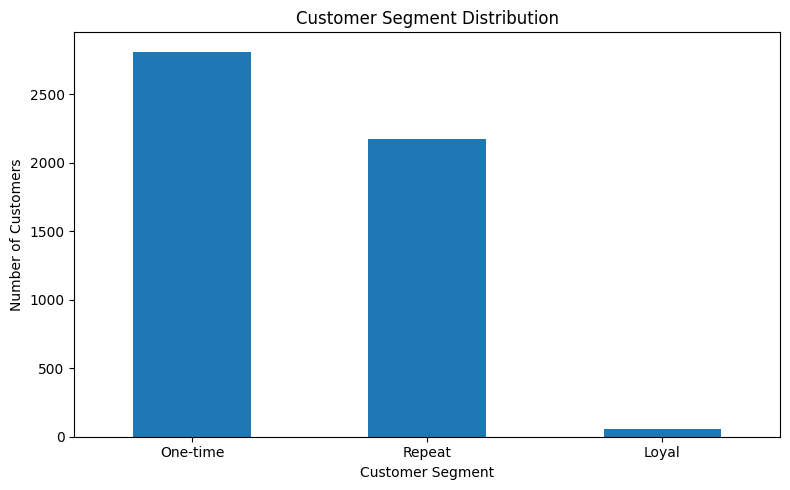

In [302]:
import matplotlib.pyplot as plt

segment_counts = customer_analysis["Customer Segment"].value_counts()

plt.figure(figsize=(8, 5))
segment_counts.plot(kind="bar")
plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

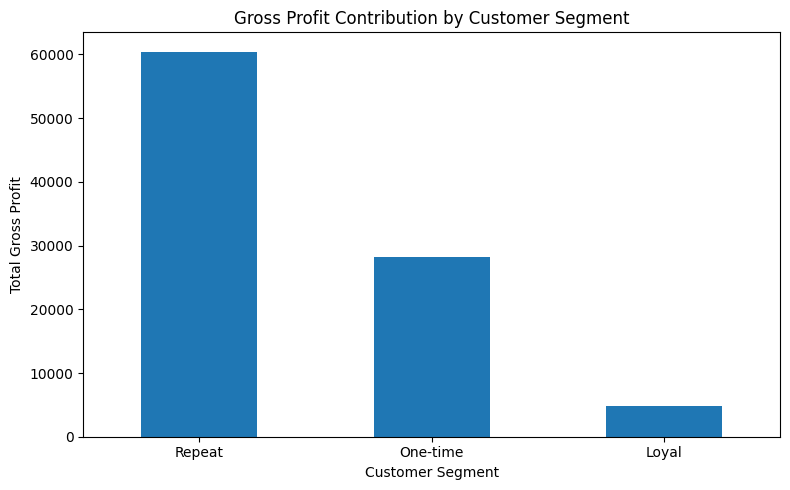

In [304]:
import matplotlib.pyplot as plt

segment_profit = (
    customer_analysis
    .groupby("Customer Segment", observed=True)["Total_Gross_Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
segment_profit.plot(kind="bar")
plt.title("Gross Profit Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Gross Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

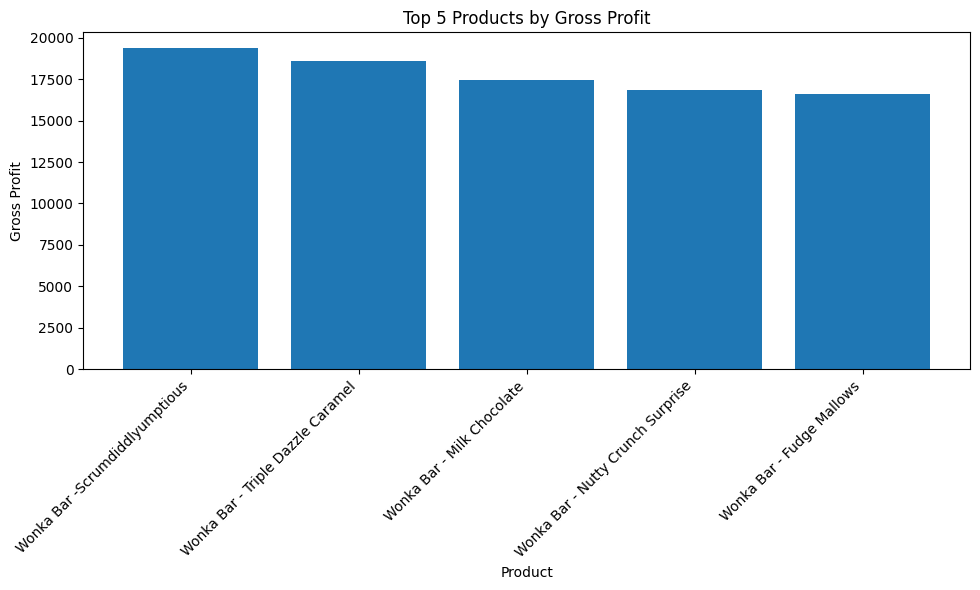

In [305]:
import matplotlib.pyplot as plt

top_5_products = (
    product_performance
    .sort_values("Total_Gross_Profit", ascending=False)
    .head(5)
)

plt.figure(figsize=(10, 6))
plt.bar(
    top_5_products["Product Name"],
    top_5_products["Total_Gross_Profit"]
)

plt.title("Top 5 Products by Gross Profit")
plt.xlabel("Product")
plt.ylabel("Gross Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

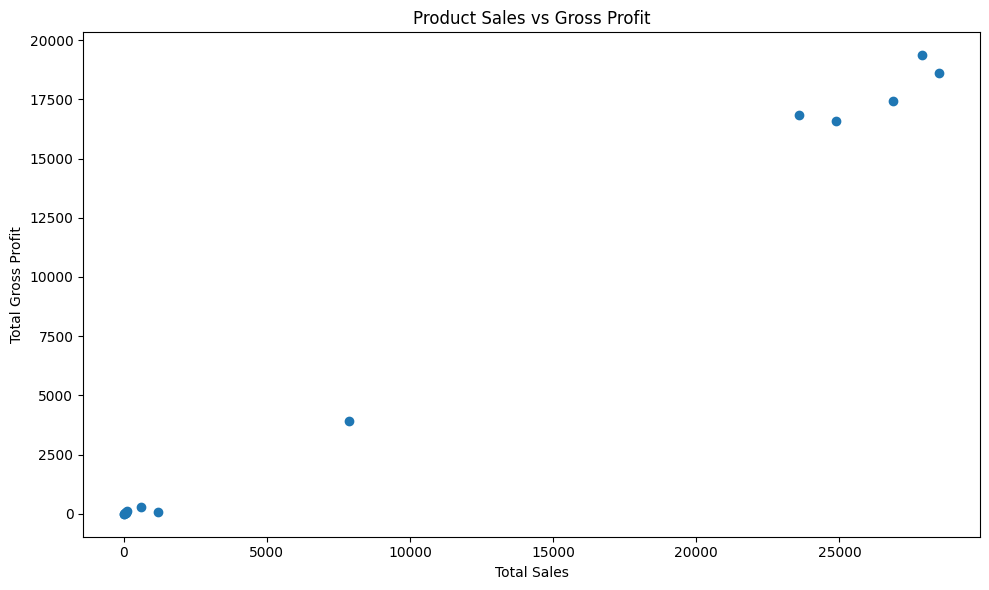

In [306]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    product_performance["Total_Sales"],
    product_performance["Total_Gross_Profit"]
)

plt.xlabel("Total Sales")
plt.ylabel("Total Gross Profit")
plt.title("Product Sales vs Gross Profit")

plt.tight_layout()
plt.show()

In [308]:
product_performance["Performance_Category"] = "Normal"

product_performance.loc[
    (product_performance["Total_Sales"] >= 1000) &
    (product_performance["Gross_Margin (%)"] >= 65),
    "Performance_Category"
] = "High Sales + High Margin"

product_performance.loc[
    (product_performance["Total_Sales"] >= 500) &
    (product_performance["Gross_Margin (%)"] < 60),
    "Performance_Category"
] = "High Sales + Low Margin"

product_performance.loc[
    (product_performance["Total_Sales"] < 1000) &
    (product_performance["Gross_Margin (%)"] >= 65),
    "Performance_Category"
] = "Low Sales + High Margin"

product_performance[
    [
        "Product Name",
        "Total_Sales",
        "Total_Gross_Profit",
        "Gross_Margin (%)",
        "Performance_Category"
    ]
].sort_values(
    "Total_Gross_Profit",
    ascending=False
)

,Product Name,Total_Sales,Total_Gross_Profit,Gross_Margin (%),Performance_Category
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.444444,High Sales + High Margin
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.333333,High Sales + High Margin
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.923077,Normal
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.346705,High Sales + High Margin
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.666667,High Sales + High Margin
6,Lickable Wallpaper,7860.00,3930.00,50.000000,High Sales + Low Margin
14,Wonka Gum,597.50,310.70,52.000000,High Sales + Low Margin
0,Everlasting Gobstopper,130.00,104.00,80.000000,Low Sales + High Margin
4,Kazookles,1205.75,92.75,7.692308,High Sales + Low Margin
3,Hair Toffee,76.50,59.50,77.777778,Low Sales + High Margin


In [309]:
product_strategy = (
    product_performance[
        [
            "Product Name",
            "Total_Sales",
            "Total_Gross_Profit",
            "Gross_Margin (%)",
            "Profit_Contribution (%)"
        ]
    ]
    .sort_values("Total_Gross_Profit", ascending=False)
)

product_strategy

,Product Name,Total_Sales,Total_Gross_Profit,Gross_Margin (%),Profit_Contribution (%)
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.444444,20.715882
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.333333,19.916141
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.923077,18.667431
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.346705,18.000263
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.666667,17.758030
6,Lickable Wallpaper,7860.00,3930.00,50.000000,4.205782
14,Wonka Gum,597.50,310.70,52.000000,0.332503
0,Everlasting Gobstopper,130.00,104.00,80.000000,0.111298
4,Kazookles,1205.75,92.75,7.692308,0.099259
3,Hair Toffee,76.50,59.50,77.777778,0.063675


In [310]:
product_strategy.head(5)

,Product Name,Total_Sales,Total_Gross_Profit,Gross_Margin (%),Profit_Contribution (%)
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.444444,20.715882
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.333333,19.916141
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.923077,18.667431
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.346705,18.000263
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.666667,17.758030


In [311]:
region_performance = (
    df.groupby("Region")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Gross_Profit=("Gross Profit", "sum"),
        Total_Units=("Units", "sum")
    )
    .reset_index()
)

region_performance["Gross_Margin (%)"] = (
    region_performance["Total_Gross_Profit"]
    / region_performance["Total_Sales"]
) * 100

region_performance["Profit_Contribution (%)"] = (
    region_performance["Total_Gross_Profit"]
    / region_performance["Total_Gross_Profit"].sum()
) * 100

region_performance.sort_values(
    "Total_Gross_Profit",
    ascending=False
)

,Region,Total_Sales,Total_Gross_Profit,Total_Units,Gross_Margin (%),Profit_Contribution (%)
3,Pacific,46301.53,30485.94,12466,65.842187,32.625242
0,Atlantic,41197.24,26973.70,11159,65.474532,28.866537
2,Interior,32037.60,21282.49,8820,66.429726,22.775955
1,Gulf,22247.26,14700.67,6209,66.078564,15.732266


Pacific: Protect and expand.
Interior: Investigate what drives its high margin and replicate those practices.
Atlantic: Maintain and optimize.
Gulf: Focus on increasing sales volume rather than aggressively cutting costs.

In [312]:
region_segment_performance = (
    df.merge(
        customer_analysis[["Customer ID", "Customer Segment"]],
        on="Customer ID",
        how="left"
    )
    .groupby(
        ["Region", "Customer Segment"],
        observed=True
    )
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Gross_Profit=("Gross Profit", "sum"),
        Customers=("Customer ID", "nunique")
    )
    .reset_index()
)

region_segment_performance["Gross_Margin (%)"] = (
    region_segment_performance["Total_Gross_Profit"]
    / region_segment_performance["Total_Sales"]
) * 100

region_segment_performance.sort_values(
    "Total_Gross_Profit",
    ascending=False
)

,Region,Customer Segment,Total_Sales,Total_Gross_Profit,Customers,Gross_Margin (%)
10,Pacific,Repeat,28832.19,19086.40,683,66.198232
1,Atlantic,Repeat,27088.61,17719.81,637,65.414246
7,Interior,Repeat,21504.65,14228.88,513,66.166527
4,Gulf,Repeat,14231.19,9418.78,345,66.184065
9,Pacific,One-time,13890.49,9137.03,905,65.779033
0,Atlantic,One-time,12151.31,7982.93,784,65.696044
6,Interior,One-time,9644.76,6472.60,653,67.110016
3,Gulf,One-time,6947.65,4604.25,469,66.270609
11,Pacific,Loyal,3578.85,2262.51,26,63.218911
2,Atlantic,Loyal,1957.32,1270.96,14,64.933685


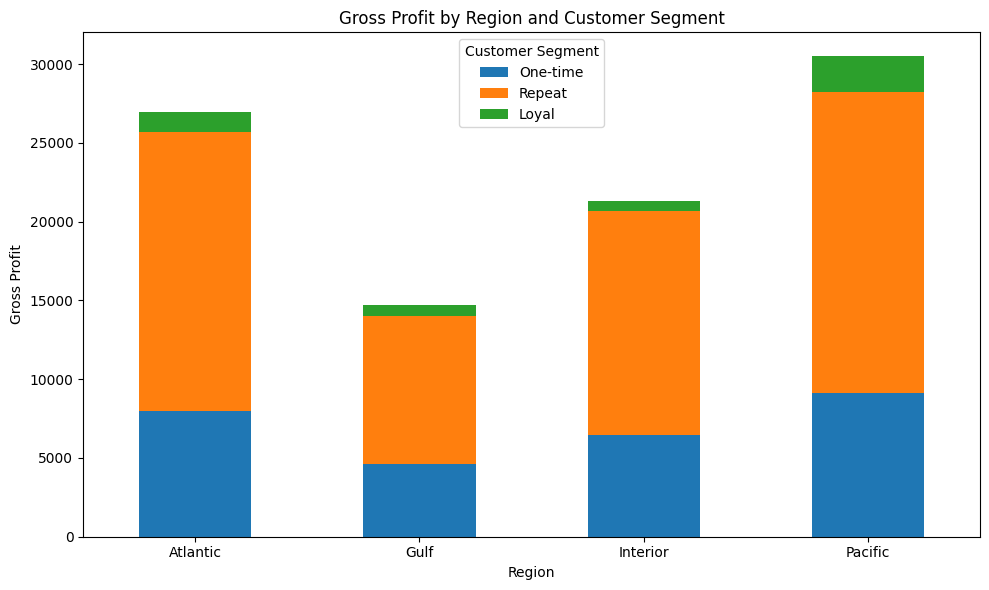

In [313]:
import matplotlib.pyplot as plt

region_segment_pivot = (
    region_segment_performance
    .pivot(
        index="Region",
        columns="Customer Segment",
        values="Total_Gross_Profit"
    )
    .fillna(0)
)

region_segment_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Gross Profit by Region and Customer Segment")
plt.xlabel("Region")
plt.ylabel("Gross Profit")
plt.xticks(rotation=0)
plt.legend(title="Customer Segment")
plt.tight_layout()
plt.show()

In [314]:
shipping_performance = (
    df.groupby("Ship Mode")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Gross_Profit=("Gross Profit", "sum"),
        Total_Units=("Units", "sum")
    )
    .reset_index()
)

shipping_performance["Gross_Margin (%)"] = (
    shipping_performance["Total_Gross_Profit"]
    / shipping_performance["Total_Sales"]
) * 100

shipping_performance["Profit_Contribution (%)"] = (
    shipping_performance["Total_Gross_Profit"]
    / shipping_performance["Total_Gross_Profit"].sum()
) * 100

shipping_performance.sort_values(
    "Total_Gross_Profit",
    ascending=False
)

,Ship Mode,Total_Sales,Total_Gross_Profit,Total_Units,Gross_Margin (%),Profit_Contribution (%)
3,Standard Class,85490.35,56424.46,23409,66.000970,60.383957
2,Second Class,27860.22,18306.52,7546,65.708455,19.591151
0,First Class,21319.39,14011.09,5724,65.719939,14.994296
1,Same Day,7113.67,4700.73,1975,66.080237,5.030596


In [315]:
shipping_region_performance = (
    df.groupby(["Region", "Ship Mode"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Gross_Profit=("Gross Profit", "sum"),
        Total_Units=("Units", "sum")
    )
    .reset_index()
)

shipping_region_performance["Gross_Margin (%)"] = (
    shipping_region_performance["Total_Gross_Profit"]
    / shipping_region_performance["Total_Sales"]
) * 100

shipping_region_performance.sort_values(
    "Total_Gross_Profit",
    ascending=False
)

,Region,Ship Mode,Total_Sales,Total_Gross_Profit,Total_Units,Gross_Margin (%)
15,Pacific,Standard Class,27829.05,18353.58,7510,65.951155
3,Atlantic,Standard Class,24394.28,15978.33,6669,65.500314
11,Interior,Standard Class,19703.42,13131.28,5469,66.644674
7,Gulf,Standard Class,13563.60,8961.27,3761,66.068522
14,Pacific,Second Class,8835.13,5773.27,2383,65.344483
2,Atlantic,Second Class,7670.60,5031.62,2074,65.596172
12,Pacific,First Class,7245.81,4772.31,1902,65.863030
0,Atlantic,First Class,6975.24,4546.35,1828,65.178402
10,Interior,Second Class,6739.87,4445.91,1795,65.964329
6,Gulf,Second Class,4614.62,3055.72,1294,66.218237


In [316]:
shipping_segment_performance = (
    df.merge(
        customer_analysis[["Customer ID", "Customer Segment"]],
        on="Customer ID",
        how="left"
    )
    .groupby(
        ["Customer Segment", "Ship Mode"],
        observed=True
    )
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Gross_Profit=("Gross Profit", "sum"),
        Customers=("Customer ID", "nunique")
    )
    .reset_index()
)

shipping_segment_performance["Gross_Margin (%)"] = (
    shipping_segment_performance["Total_Gross_Profit"]
    / shipping_segment_performance["Total_Sales"]
) * 100

shipping_segment_performance.sort_values(
    "Total_Gross_Profit",
    ascending=False
)

,Customer Segment,Ship Mode,Total_Sales,Total_Gross_Profit,Customers,Gross_Margin (%)
7,Repeat,Standard Class,54571.27,36075.61,1306,66.107331
3,One-time,Standard Class,25976.29,17192.74,1686,66.186280
6,Repeat,Second Class,18232.40,11970.36,415,65.654330
4,Repeat,First Class,14611.60,9595.29,345,65.668989
2,One-time,Second Class,8012.02,5301.62,538,66.170828
0,One-time,First Class,6444.54,4244.33,439,65.859317
11,Loyal,Standard Class,4942.79,3156.11,35,63.852804
5,Repeat,Same Day,4241.37,2812.61,110,66.313715
1,One-time,Same Day,2201.36,1458.12,148,66.237235
10,Loyal,Second Class,1615.80,1034.54,13,64.026488


In [317]:
division_performance = (
    df.groupby("Division")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Gross_Profit=("Gross Profit", "sum"),
        Total_Units=("Units", "sum")
    )
    .reset_index()
)

division_performance["Gross_Margin (%)"] = (
    division_performance["Total_Gross_Profit"]
    / division_performance["Total_Sales"]
) * 100

division_performance["Profit_Contribution (%)"] = (
    division_performance["Total_Gross_Profit"]
    / division_performance["Total_Gross_Profit"].sum()
) * 100

division_performance.sort_values(
    "Total_Gross_Profit",
    ascending=False
)

,Division,Total_Sales,Total_Gross_Profit,Total_Units,Gross_Margin (%),Profit_Contribution (%)
0,Chocolate,131692.90,88824.62,37275,67.448298,95.057747
1,Other,9663.25,4333.45,1242,44.844643,4.637543
2,Sugar,427.48,284.73,137,66.606625,0.304710


In [318]:
division_segment_performance = (
    df.merge(
        customer_analysis[["Customer ID", "Customer Segment"]],
        on="Customer ID",
        how="left"
    )
    .groupby(
        ["Division", "Customer Segment"],
        observed=True
    )
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Gross_Profit=("Gross Profit", "sum"),
        Customers=("Customer ID", "nunique")
    )
    .reset_index()
)

division_segment_performance["Gross_Margin (%)"] = (
    division_segment_performance["Total_Gross_Profit"]
    / division_segment_performance["Total_Sales"]
) * 100

division_segment_performance.sort_values(
    "Total_Gross_Profit",
    ascending=False
)

,Division,Customer Segment,Total_Sales,Total_Gross_Profit,Customers,Gross_Margin (%)
1,Chocolate,Repeat,85369.23,57590.21,2175,67.460149
0,Chocolate,One-time,40257.33,27143.83,2716,67.425808
2,Chocolate,Loyal,6066.34,4090.58,57,67.430774
4,Other,Repeat,5955.75,2633.95,193,44.225328
3,Other,One-time,2308.00,1014.40,82,43.951473
5,Other,Loyal,1399.50,685.10,14,48.953198
7,Sugar,Repeat,331.66,229.71,25,69.260689
6,Sugar,One-time,68.88,38.58,13,56.010453
8,Sugar,Loyal,26.94,16.44,1,61.024499


In [319]:
overall_kpis = {
    "Total Sales": df["Sales"].sum(),
    "Total Gross Profit": df["Gross Profit"].sum(),
    "Total Units": df["Units"].sum(),
    "Total Customers": customer_analysis["Customer ID"].nunique(),
    "Overall Gross Margin (%)": (
        df["Gross Profit"].sum() / df["Sales"].sum()
    ) * 100
}

overall_kpis

{'Total Sales': np.float64(141783.63),
 'Total Gross Profit': np.float64(93442.8),
 'Total Units': np.int64(38654),
 'Total Customers': 5044,
 'Overall Gross Margin (%)': np.float64(65.90521063679918)}

The business is highly profitable overall, but profit is concentrated in a small number of products, while customer loyalty is relatively weak. The strongest growth opportunity is to increase purchase frequency and move valuable Repeat customers toward Loyal behavior. At the same time, the company should protect its top Chocolate products and investigate low-margin products such as Kazookles and the Other division.

In [320]:
print("========== BUSINESS KPI SUMMARY ==========")
print(f"Total Sales:        {df['Sales'].sum():,.2f}")
print(f"Total Gross Profit: {df['Gross Profit'].sum():,.2f}")
print(f"Total Units Sold:   {df['Units'].sum():,}")
print(f"Total Customers:    {customer_analysis['Customer ID'].nunique():,}")
print(f"Gross Margin:       {(df['Gross Profit'].sum() / df['Sales'].sum()) * 100:.2f}%")

========== BUSINESS KPI SUMMARY ==========
Total Sales:        141,783.63
Total Gross Profit: 93,442.80
Total Units Sold:   38,654
Total Customers:    5,044
Gross Margin:       65.91%


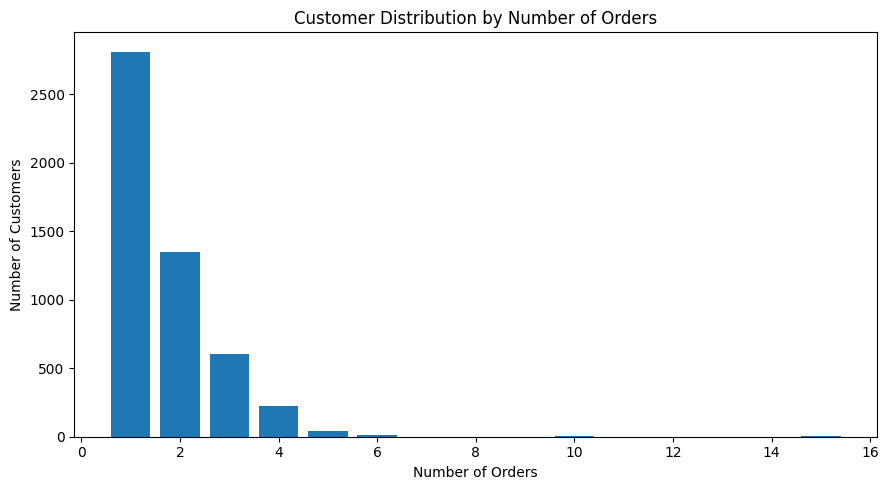

In [321]:
import matplotlib.pyplot as plt

order_counts = (
    customer_value_by_orders
    .groupby("Order_Count")["Customer ID"]
    .count()
)

plt.figure(figsize=(9, 5))
plt.bar(order_counts.index, order_counts.values)

plt.title("Customer Distribution by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

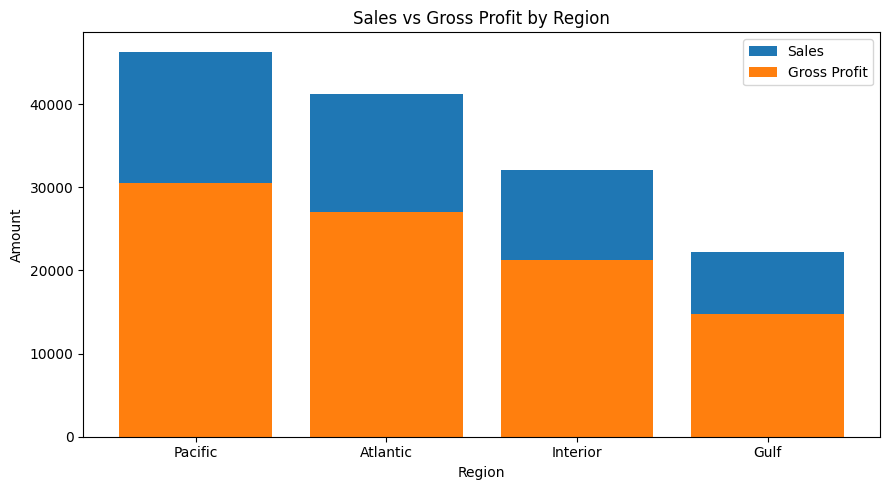

In [322]:
import matplotlib.pyplot as plt

region_chart = region_performance.sort_values(
    "Total_Gross_Profit",
    ascending=False
)

x = range(len(region_chart))

plt.figure(figsize=(9, 5))

plt.bar(
    x,
    region_chart["Total_Sales"],
    label="Sales"
)

plt.bar(
    x,
    region_chart["Total_Gross_Profit"],
    label="Gross Profit"
)

plt.xticks(x, region_chart["Region"])
plt.xlabel("Region")
plt.ylabel("Amount")
plt.title("Sales vs Gross Profit by Region")
plt.legend()

plt.tight_layout()
plt.show()

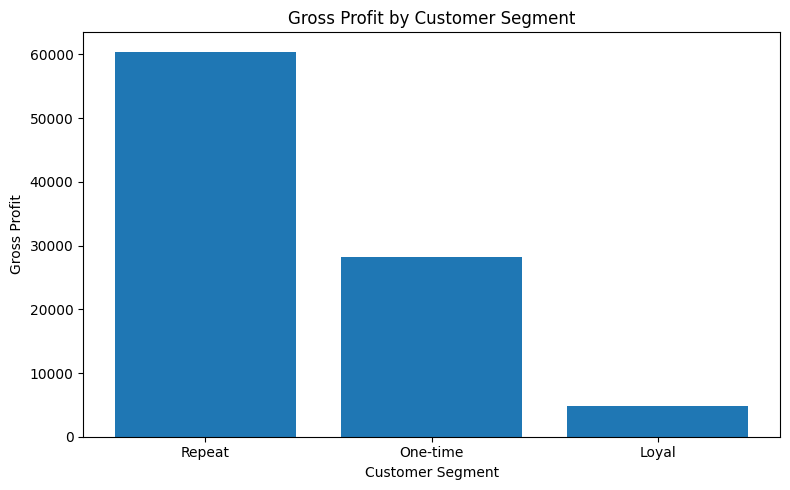

In [323]:
import matplotlib.pyplot as plt

segment_chart = (
    customer_analysis
    .groupby("Customer Segment", observed=True)["Total_Gross_Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    segment_chart.index,
    segment_chart.values
)

plt.title("Gross Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Gross Profit")

plt.tight_layout()
plt.show()

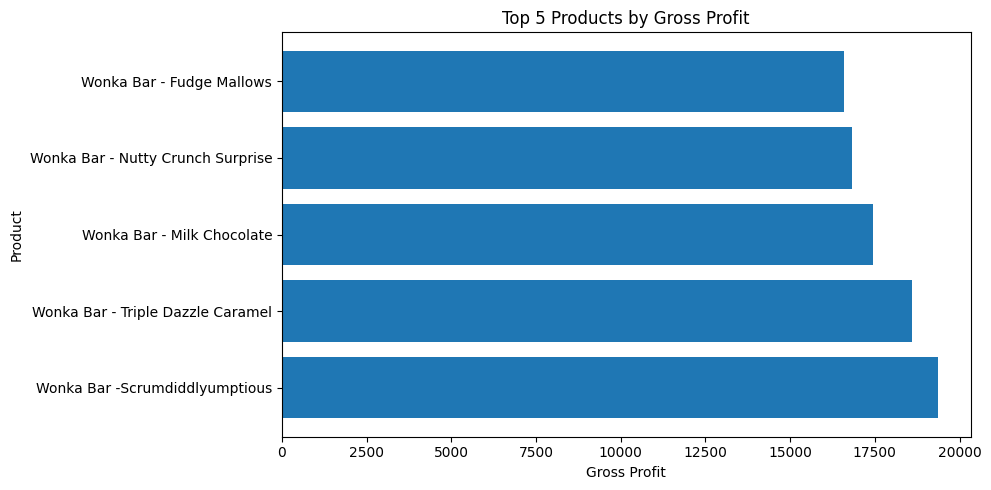

In [324]:
import matplotlib.pyplot as plt

top_5_products = (
    product_performance
    .sort_values("Total_Gross_Profit", ascending=False)
    .head(5)
)

plt.figure(figsize=(10, 5))

plt.barh(
    top_5_products["Product Name"],
    top_5_products["Total_Gross_Profit"]
)

plt.title("Top 5 Products by Gross Profit")
plt.xlabel("Gross Profit")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [325]:
dashboard_kpis = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Gross Profit",
        "Total Units",
        "Total Customers",
        "Gross Margin (%)",
        "One-time Customers (%)",
        "Repeat Customers (%)",
        "Loyal Customers (%)",
        "1→2 Retention (%)"
    ],
    "Value": [
        df["Sales"].sum(),
        df["Gross Profit"].sum(),
        df["Units"].sum(),
        customer_analysis["Customer ID"].nunique(),
        (df["Gross Profit"].sum() / df["Sales"].sum()) * 100,
        (2811 / 5044) * 100,
        (2176 / 5044) * 100,
        (57 / 5044) * 100,
        (1351 / 2811) * 100
    ]
})

dashboard_kpis

,KPI,Value
0,Total Sales,141783.630000
1,Total Gross Profit,93442.800000
2,Total Units,38654.000000
3,Total Customers,5044.000000
4,Gross Margin (%),65.905211
5,One-time Customers (%),55.729580
6,Repeat Customers (%),43.140365
7,Loyal Customers (%),1.130056
8,1→2 Retention (%),48.061188


In [326]:
segment_dashboard = (
    customer_analysis
    .groupby("Customer Segment", observed=True)
    .agg(
        Customers=("Customer ID", "count"),
        Total_Sales=("Total_Sales", "sum"),
        Total_Profit=("Total_Gross_Profit", "sum"),
        Average_Profit=("Total_Gross_Profit", "mean")
    )
    .reset_index()
)

segment_dashboard["Customer_%"] = (
    segment_dashboard["Customers"]
    / segment_dashboard["Customers"].sum()
) * 100

segment_dashboard["Profit_%"] = (
    segment_dashboard["Total_Profit"]
    / segment_dashboard["Total_Profit"].sum()
) * 100

segment_dashboard.sort_values(
    "Total_Profit",
    ascending=False
)

,Customer Segment,Customers,Total_Sales,Total_Profit,Average_Profit,Customer_%,Profit_%
1,Repeat,2176,91656.64,60453.87,27.782109,43.140365,64.696124
0,One-time,2811,42634.21,28196.81,10.030882,55.729580,30.175476
2,Loyal,57,7492.78,4792.12,84.072281,1.130056,5.128399


In [327]:
product_dashboard = (
    product_performance
    .copy()
)

product_dashboard["Sales_%"] = (
    product_dashboard["Total_Sales"]
    / product_dashboard["Total_Sales"].sum()
) * 100

product_dashboard["Profit_%"] = (
    product_dashboard["Total_Gross_Profit"]
    / product_dashboard["Total_Gross_Profit"].sum()
) * 100

product_dashboard = product_dashboard[
    [
        "Product Name",
        "Total_Sales",
        "Total_Gross_Profit",
        "Gross_Margin (%)",
        "Sales_%",
        "Profit_%"
    ]
].sort_values(
    "Total_Gross_Profit",
    ascending=False
)

product_dashboard

,Product Name,Total_Sales,Total_Gross_Profit,Gross_Margin (%),Sales_%,Profit_%
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.444444,19.660098,20.715882
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.333333,20.090472,19.916141
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.923077,18.949825,18.667431
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.346705,16.627413,18.000263
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.666667,17.555200,17.758030
6,Lickable Wallpaper,7860.00,3930.00,50.000000,5.543658,4.205782
14,Wonka Gum,597.50,310.70,52.000000,0.421417,0.332503
0,Everlasting Gobstopper,130.00,104.00,80.000000,0.091689,0.111298
4,Kazookles,1205.75,92.75,7.692308,0.850416,0.099259
3,Hair Toffee,76.50,59.50,77.777778,0.053955,0.063675


In [328]:
region_dashboard = region_performance.copy()

region_dashboard["Sales_%"] = (
    region_dashboard["Total_Sales"]
    / region_dashboard["Total_Sales"].sum()
) * 100

region_dashboard["Profit_%"] = (
    region_dashboard["Total_Gross_Profit"]
    / region_dashboard["Total_Gross_Profit"].sum()
) * 100

region_dashboard = region_dashboard[
    [
        "Region",
        "Total_Sales",
        "Total_Gross_Profit",
        "Gross_Margin (%)",
        "Sales_%",
        "Profit_%"
    ]
].sort_values(
    "Total_Gross_Profit",
    ascending=False
)

region_dashboard

,Region,Total_Sales,Total_Gross_Profit,Gross_Margin (%),Sales_%,Profit_%
3,Pacific,46301.53,30485.94,65.842187,32.656471,32.625242
0,Atlantic,41197.24,26973.70,65.474532,29.056415,28.866537
2,Interior,32037.60,21282.49,66.429726,22.596121,22.775955
1,Gulf,22247.26,14700.67,66.078564,15.690993,15.732266


In [329]:
region_dashboard = region_performance.copy()

region_dashboard["Sales_%"] = (
    region_dashboard["Total_Sales"]
    / region_dashboard["Total_Sales"].sum()
) * 100

region_dashboard["Profit_%"] = (
    region_dashboard["Total_Gross_Profit"]
    / region_dashboard["Total_Gross_Profit"].sum()
) * 100

region_dashboard = region_dashboard[
    [
        "Region",
        "Total_Sales",
        "Total_Gross_Profit",
        "Gross_Margin (%)",
        "Sales_%",
        "Profit_%"
    ]
].sort_values(
    "Total_Gross_Profit",
    ascending=False
)

region_dashboard


,Region,Total_Sales,Total_Gross_Profit,Gross_Margin (%),Sales_%,Profit_%
3,Pacific,46301.53,30485.94,65.842187,32.656471,32.625242
0,Atlantic,41197.24,26973.70,65.474532,29.056415,28.866537
2,Interior,32037.60,21282.49,66.429726,22.596121,22.775955
1,Gulf,22247.26,14700.67,66.078564,15.690993,15.732266


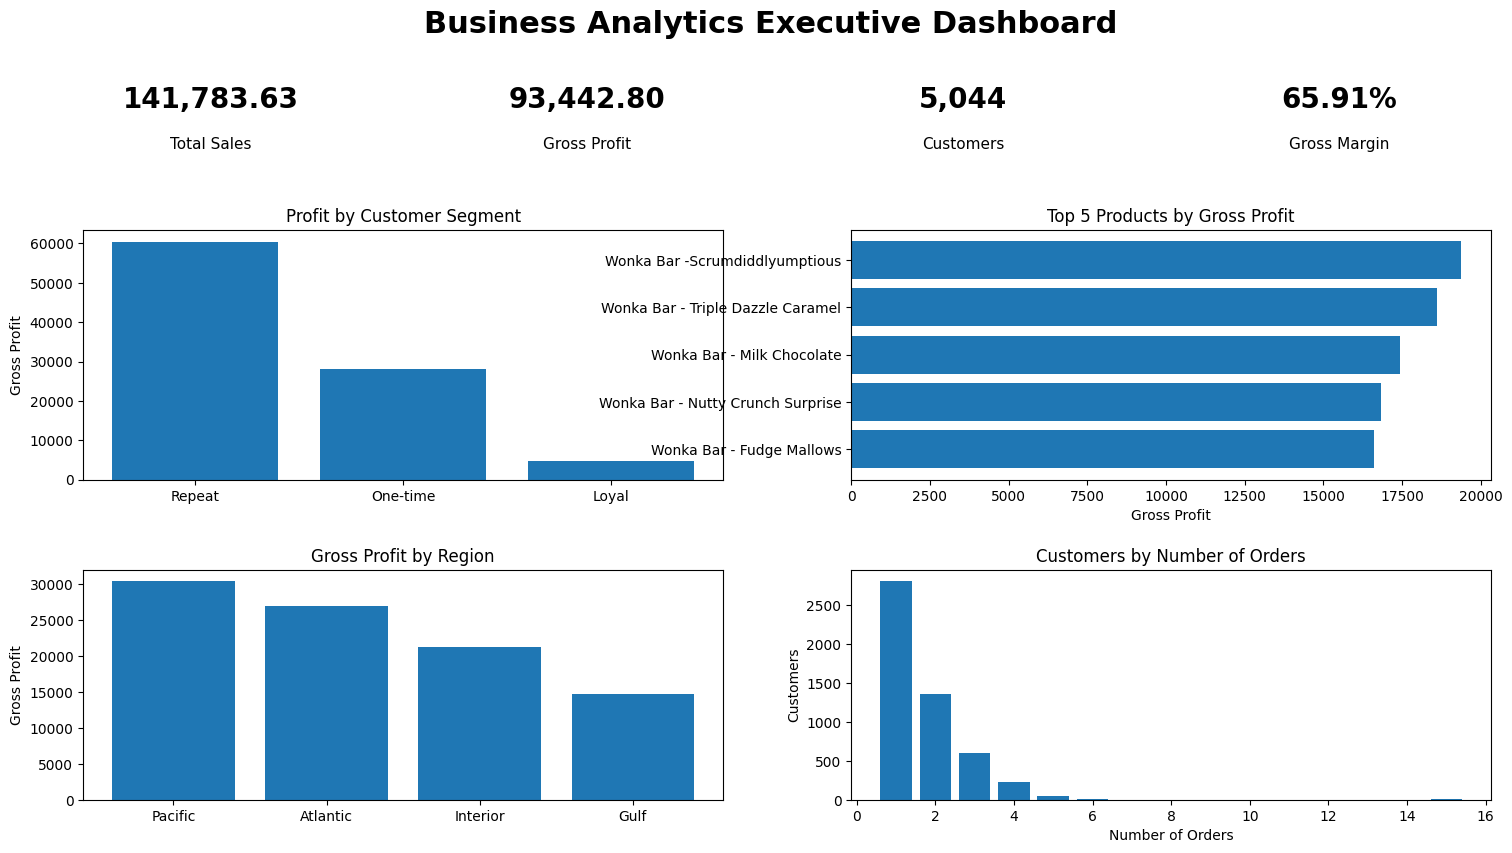

In [330]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(16, 10))

# ---------------- KPI CARDS ----------------
kpis = [
    ("Total Sales", f"{df['Sales'].sum():,.2f}"),
    ("Gross Profit", f"{df['Gross Profit'].sum():,.2f}"),
    ("Customers", f"{customer_analysis['Customer ID'].nunique():,}"),
    ("Gross Margin", f"{(df['Gross Profit'].sum()/df['Sales'].sum())*100:.2f}%")
]

for i, (title, value) in enumerate(kpis):
    ax = fig.add_axes([
        0.05 + i * 0.235,
        0.82,
        0.20,
        0.10
    ])

    ax.text(
        0.5, 0.60, value,
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.15, title,
        ha="center",
        va="center",
        fontsize=11
    )

    ax.axis("off")


# ---------------- CUSTOMER SEGMENT ----------------
ax1 = fig.add_axes([0.07, 0.50, 0.40, 0.25])

segment_chart = (
    customer_analysis
    .groupby("Customer Segment", observed=True)["Total_Gross_Profit"]
    .sum()
    .sort_values(ascending=False)
)

ax1.bar(
    segment_chart.index,
    segment_chart.values
)

ax1.set_title("Profit by Customer Segment")
ax1.set_ylabel("Gross Profit")


# ---------------- TOP PRODUCTS ----------------
ax2 = fig.add_axes([0.55, 0.50, 0.40, 0.25])

top_products = (
    product_performance
    .sort_values("Total_Gross_Profit", ascending=False)
    .head(5)
    .sort_values("Total_Gross_Profit")
)

ax2.barh(
    top_products["Product Name"],
    top_products["Total_Gross_Profit"]
)

ax2.set_title("Top 5 Products by Gross Profit")
ax2.set_xlabel("Gross Profit")


# ---------------- REGION ----------------
ax3 = fig.add_axes([0.07, 0.18, 0.40, 0.23])

ax3.bar(
    region_dashboard["Region"],
    region_dashboard["Total_Gross_Profit"]
)

ax3.set_title("Gross Profit by Region")
ax3.set_ylabel("Gross Profit")


# ---------------- ORDER FREQUENCY ----------------
ax4 = fig.add_axes([0.55, 0.18, 0.40, 0.23])

order_counts = (
    customer_value_by_orders
    .groupby("Order_Count")["Customer ID"]
    .count()
)

ax4.bar(
    order_counts.index,
    order_counts.values
)

ax4.set_title("Customers by Number of Orders")
ax4.set_xlabel("Number of Orders")
ax4.set_ylabel("Customers")


fig.suptitle(
    "Business Analytics Executive Dashboard",
    fontsize=22,
    fontweight="bold",
    y=0.97
)

plt.show()

In [331]:
final_insights = pd.DataFrame({
    "Area": [
        "Customer Retention",
        "Customer Segmentation",
        "Customer Loyalty",
        "Product Concentration",
        "Product Profitability",
        "Regional Performance",
        "Division Performance",
        "Shipping"
    ],
    "Key_Finding": [
        "55.73% of customers are One-time customers",
        "Repeat customers generate 64.70% of total profit",
        "Loyal customers generate the highest average profit per customer",
        "Top 5 products generate about 95% of total profit",
        "Kazookles has only a 7.69% gross margin",
        "Pacific generates the highest total profit",
        "Chocolate generates 95.06% of total profit",
        "Standard Class generates the highest total profit"
    ],
    "Business_Implication": [
        "Strong opportunity to increase second purchases",
        "Repeat customers are the main profit engine",
        "Loyal customers are highly valuable and should be protected",
        "Inventory and marketing should prioritize the top products",
        "Pricing and cost structure should be investigated",
        "Pacific should be protected while Gulf needs volume growth",
        "Chocolate is the core business and should be prioritized",
        "Shipping mode is mainly a volume difference, not a major margin issue"
    ]
})

final_insights

,Area,Key_Finding,Business_Implication
0,Customer Retention,55.73% of customers are One-time customers,Strong opportunity to increase second purchases
1,Customer Segmentation,Repeat customers generate 64.70% of total profit,Repeat customers are the main profit engine
2,Customer Loyalty,Loyal customers generate the highest average p...,Loyal customers are highly valuable and should...
3,Product Concentration,Top 5 products generate about 95% of total profit,Inventory and marketing should prioritize the ...
4,Product Profitability,Kazookles has only a 7.69% gross margin,Pricing and cost structure should be investigated
5,Regional Performance,Pacific generates the highest total profit,Pacific should be protected while Gulf needs v...
6,Division Performance,Chocolate generates 95.06% of total profit,Chocolate is the core business and should be p...
7,Shipping,Standard Class generates the highest total profit,"Shipping mode is mainly a volume difference, n..."


In [332]:
limitations = [
    "The conversion and profit opportunity calculations are scenario estimates, not guaranteed future results.",
    "Customer segments are based on observed purchase behavior in the dataset.",
    "The analysis identifies associations between customer behavior and profitability, but does not prove causation.",
    "Some high-order customer groups contain very few customers, so their averages should be interpreted cautiously.",
    "The dataset represents a specific period and may not reflect future customer behavior.",
    "External factors such as marketing campaigns, seasonality, competitor pricing, and customer demographics were not included."
]

for i, limitation in enumerate(limitations, 1):
    print(f"{i}. {limitation}")

1. The conversion and profit opportunity calculations are scenario estimates, not guaranteed future results.
2. Customer segments are based on observed purchase behavior in the dataset.
3. The analysis identifies associations between customer behavior and profitability, but does not prove causation.
4. Some high-order customer groups contain very few customers, so their averages should be interpreted cautiously.
5. The dataset represents a specific period and may not reflect future customer behavior.
6. External factors such as marketing campaigns, seasonality, competitor pricing, and customer demographics were not included.


In [333]:
final_conclusion = """
The analysis of 5,044 customers and 38,654 units shows that the business generated
141,783.63 in sales and 93,442.80 in gross profit, with an overall gross margin
of 65.91%.

Customer retention is the most important growth opportunity. One-time customers
represent 55.73% of the customer base, while only 1.13% are classified as Loyal.
Repeat customers are the main profit engine, contributing approximately 64.70% of
total gross profit, while Loyal customers generate the highest average profit per
customer.

Product profitability is highly concentrated. The top five products generate about
95% of total gross profit, while Kazookles has a very low 7.69% gross margin and
requires further investigation.

Regionally, Pacific generates the highest total sales and gross profit, while
Interior has the highest gross margin. At the division level, Chocolate dominates
the business and contributes approximately 95.06% of total gross profit.

Overall, the strongest business strategy is to increase customer purchase frequency,
convert more One-time customers into Repeat customers, develop high-value Repeat
customers into Loyal customers, protect the highest-profit products, and investigate
low-margin products and divisions.
"""

print(final_conclusion)


The analysis of 5,044 customers and 38,654 units shows that the business generated
141,783.63 in sales and 93,442.80 in gross profit, with an overall gross margin
of 65.91%.

Customer retention is the most important growth opportunity. One-time customers
represent 55.73% of the customer base, while only 1.13% are classified as Loyal.
Repeat customers are the main profit engine, contributing approximately 64.70% of
total gross profit, while Loyal customers generate the highest average profit per
customer.

Product profitability is highly concentrated. The top five products generate about
95% of total gross profit, while Kazookles has a very low 7.69% gross margin and
requires further investigation.

Regionally, Pacific generates the highest total sales and gross profit, while
Interior has the highest gross margin. At the division level, Chocolate dominates
the business and contributes approximately 95.06% of total gross profit.

Overall, the strongest business strategy is to increase c

In [334]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDataset Shape:")
print(df.shape)

Missing Values:
Row ID                     0
Order ID                   0
Order Date                 0
Ship Date                  0
Ship Mode                  0
Customer ID                0
Country/Region             0
City                       0
State/Province             0
Postal Code                0
Division                   0
Region                     0
Product ID                 0
Product Name               0
Sales                      0
Units                      0
Gross Profit               0
Cost                       0
Gross Margin (%)           0
Profit per Unit            0
Profit Contribution (%)    0
dtype: int64

Duplicate Rows:
0

Dataset Shape:
(10194, 21)


# Executive Summary

## Business Performance

The dataset contains 10,194 transaction records representing 5,044 unique customers across 21 columns.

The business generated total sales of 141,783.63 and gross profit of 93,442.80, resulting in an overall gross margin of 65.91%.

## Customer Insights

Customer retention is the major growth opportunity. One-time customers represent 55.73% of the customer base, while Repeat customers represent 43.14% and Loyal customers only 1.13%.

Repeat customers generate 64.70% of total gross profit, making them the primary profit-driving customer segment. Loyal customers generate the highest average profit per customer at 84.07.

The 1-to-2 order retention rate is 48.06%, making the first-to-second purchase stage the largest customer retention opportunity.

## Product Insights

Product profitability is highly concentrated. The top five products generate approximately 95% of total gross profit.

Wonka Bar - Scrumdiddlyumptious is the largest individual profit contributor, while Nutty Crunch Surprise has the highest margin among the major products.

Kazookles requires attention because its gross margin is only 7.69%.

## Regional Insights

Pacific is the strongest region, generating 46,301.53 in sales and 30,485.94 in gross profit.

Interior has the highest regional gross margin at 66.43%.

Gulf generates the lowest absolute sales and profit, making it an opportunity for volume growth.

## Division Insights

Chocolate is the dominant division, generating 95.06% of total gross profit.

The Other division has a significantly lower gross margin of 44.84% and should be investigated for pricing, cost, and product-mix issues.

## Key Recommendations

1. Increase One-time customer conversion into Repeat customers.
2. Target high-value Repeat customers for Loyal conversion.
3. Protect and promote the top five profit-driving products.
4. Investigate low-margin products such as Kazookles.
5. Investigate the low-margin Other division.
6. Protect Pacific's strong performance and focus on increasing sales volume in Gulf.

# Final Conclusion

The analysis of 10,194 transaction records representing 5,044 unique customers
shows that the business generated 141,783.63 in sales and 93,442.80 in gross
profit, with an overall gross margin of 65.91%.

The major opportunity is customer retention. One-time customers represent 55.73%
of the customer base, while only 1.13% are Loyal customers. Repeat customers
generate 64.70% of total gross profit, while Loyal customers have the highest
average profit per customer.

The analysis also shows that the top five products generate approximately 95% of
total gross profit. Kazookles has a low gross margin of 7.69% and requires further
investigation.

Pacific is the strongest region by total sales and profit, while Interior has the
highest regional margin. Chocolate is the dominant division, contributing 95.06%
of total gross profit.

Overall, the business should focus on improving customer retention, increasing
repeat purchases, converting high-value Repeat customers into Loyal customers,
protecting high-profit products, and investigating low-margin products and
divisions.

# Limitations

1. The conversion and profit opportunity calculations are scenario estimates, not guaranteed future results.

2. Customer segments are based on observed purchase behavior in the dataset.

3. The analysis identifies associations between customer behavior and profitability, but does not prove causation.

4. Some high-order customer groups contain very few customers, so their averages should be interpreted cautiously.

5. The dataset represents a specific period and may not reflect future customer behavior.

6. External factors such as marketing campaigns, seasonality, competitor pricing, and customer demographics were not included.


# Key Recommendations

1. **Increase One-time → Repeat conversion**
   - 55.73% of customers are One-time customers.
   - Focus on follow-up offers, personalized recommendations, and incentives for a second purchase.

2. **Convert Repeat → Loyal customers**
   - Repeat customers generate 64.70% of total profit.
   - Target high-value Repeat customers with loyalty rewards and personalized offers.

3. **Protect the top 5 products**
   - The top 5 products generate approximately 95% of total gross profit.
   - Maintain their inventory and prioritize them in marketing campaigns.

4. **Investigate low-margin products**
   - Kazookles has only a 7.69% gross margin.
   - Review its pricing, costs, discounts, and supplier expenses.

5. **Focus on regional opportunities**
   - Pacific is the strongest region by sales and profit.
   - Gulf has the lowest sales and profit, so increasing sales volume should be a priority.

6. **Protect the Chocolate division**
   - Chocolate contributes approximately 95.06% of total gross profit.
   - Maintain strong inventory availability and monitor its key products.

7. **Use shipping strategically**
   - Standard Class generates the highest total profit because of its high volume.
   - Shipping modes have similar margins, so shipping is not the main profitability issue.

# Project Summary

## Overall Business Performance

- Total Sales: 141,783.63
- Total Gross Profit: 93,442.80
- Total Units Sold: 38,654
- Total Customers: 5,044
- Overall Gross Margin: 65.91%

## Main Findings

- One-time customers represent 55.73% of the customer base.
- Repeat customers contribute 64.70% of total gross profit.
- Loyal customers generate the highest average profit per customer.
- The 1→2 order retention rate is 48.06%.
- The top 5 products generate approximately 95% of total gross profit.
- Pacific is the highest-performing region.
- Interior has the highest regional margin.
- Chocolate contributes 95.06% of total gross profit.
- Kazookles has a very low gross margin of 7.69%.

## Overall Business Opportunity

The strongest opportunity is to increase customer purchase frequency by converting One-time customers into Repeat customers and high-value Repeat customers into Loyal customers, while protecting the products and divisions that generate the majority of profit.